## **Phase 4 Web Map (Visualization)**

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.colors as mcolors
import json
import datetime
import os
import warnings
warnings.filterwarnings('ignore')


In [2]:
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'TH Sarabun New'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# ══════════════════════════════════════════════════════════════════
#  กำหนด Path และ Output ทั้งหมดในเซลล์นี้ที่เดียว
# ══════════════════════════════════════════════════════════════════

BASE_PATH = r"D:\gistnu\ST-DBSCAN\file_final\Phase 4 Final"

# ── Input (จาก Phase 3) ──────────────────────────────────────────
PATH_INPUT       = r"D:\gistnu\ST-DBSCAN\file_final\Phase 4 Final\phase 3\hotspot_classified_final.gpkg"
PATH_POLY        = r"D:\gistnu\ST-DBSCAN\file_final\Phase 4 Final\phase 3\cluster_polygons_final.gpkg"
PATH_RECUR       = r"D:\gistnu\ST-DBSCAN\file_final\Phase 4 Final\phase 3\repeat_burn_grid_final.gpkg"
PATH_CLUSTER_CSV = r"D:\gistnu\ST-DBSCAN\file_final\Phase 4 Final\phase 3\cluster_summary_final.csv"
PATH_BOUNDARY    = r"D:\gistnu\tha_admin_boundaries.shp\tha_admin2.shp"

# ── Output directory ──────────────────────────────────────────────
OUTPUT_DIR = os.path.join(BASE_PATH, "Output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Output maps + plots ───────────────────────────────────────────
PATH_MAP1      = os.path.join(OUTPUT_DIR, "map1_hotspot_by_fire_type.html")
PATH_MAP2      = os.path.join(OUTPUT_DIR, "map2_repeat_burn.html")
PATH_MAP3      = os.path.join(OUTPUT_DIR, "map3_burn_season.html")
PATH_MAP4      = os.path.join(OUTPUT_DIR, "map4_frp_intensity.html")
PATH_DASHBOARD = os.path.join(OUTPUT_DIR, "dashboard.html")

# ── ตรวจสอบ input ────────────────────────────────────────────────
for name, path in [("Classified GeoPackage", PATH_INPUT),
                   ("Cluster CSV",            PATH_CLUSTER_CSV),
                   ("Cluster Polygons",       PATH_POLY),
                   ("Boundary",               PATH_BOUNDARY)]:
    status = "✓" if os.path.exists(path) else "✗"
    print(f"{status} {name}: {os.path.basename(path)}")


✓ Classified GeoPackage: hotspot_classified_final.gpkg
✓ Cluster CSV: cluster_summary_final.csv
✓ Cluster Polygons: cluster_polygons_final.gpkg
✓ Boundary: tha_admin2.shp


In [4]:
# CELL 2 — โหลดข้อมูล
gdf        = gpd.read_file(PATH_INPUT)
df_cluster = pd.read_csv(PATH_CLUSTER_CSV)
gdf_poly  = gpd.read_file(PATH_POLY)

In [5]:
# โหลดขอบเขตอำเภอ กรองเหลือ 2 อำเภอในพื้นที่ศึกษา
boundary   = gpd.read_file(PATH_BOUNDARY)
amphoe_gdf = boundary[boundary['adm1_name'] == 'Phitsanulok'].copy().to_crs('EPSG:4326')
amphoe_gdf = amphoe_gdf[amphoe_gdf['adm2_name'].isin(['Bang Rakam', 'Mueang Phitsanulok'])].copy()
amphoe_gdf = amphoe_gdf[['adm2_name', 'adm2_name1', 'geometry', 'area_sqkm']].copy()
print(f"✓ โหลดขอบเขต: {amphoe_gdf['adm2_name'].tolist()}")


✓ โหลดขอบเขต: ['Mueang Phitsanulok', 'Bang Rakam']


In [6]:
# แปลง hotspot เป็น WGS84
gdf_wgs = gdf.to_crs('EPSG:4326')
gdf_cluster_wgs = gdf_wgs[gdf_wgs['cluster_id'] != -1].copy()
gdf_noise_wgs   = gdf_wgs[gdf_wgs['cluster_id'] == -1].copy()

In [7]:
# --- CHECKPOINT 2 ---
assert len(gdf_wgs) == len(gdf),           "✗ จำนวนแถวเปลี่ยนหลังแปลง CRS"
assert str(gdf_wgs.crs) == 'EPSG:4326',    "✗ CRS ไม่ใช่ WGS84"
assert str(amphoe_gdf.crs) == 'EPSG:4326', "✗ HDX CRS ไม่ใช่ WGS84"
assert 'fire_behavior'  in gdf_wgs.columns, "✗ ไม่มี fire_behavior"
assert 'repeat_burn'    in gdf_wgs.columns, "✗ ไม่มี repeat_burn"
assert 'n_years_active' in gdf_wgs.columns, "✗ ไม่มี n_years_active"
assert 'daynight_label' in gdf_wgs.columns, "✗ ไม่มี daynight_label"
assert 'is_day'         in gdf_wgs.columns, "✗ ไม่มี is_day"
assert 'day_pct'        in gdf_poly.columns, "✗ ไม่มี day_pct ใน cluster polygon"
assert len(amphoe_gdf) == 2,               f"✗ อำเภอไม่ครบ 2 (พบ {len(amphoe_gdf)})"
print("✓ แปลง CRS เป็น WGS84 สำเร็จ")
print(f"✓ อำเภอ: {amphoe_gdf['adm2_name'].tolist()}")


✓ แปลง CRS เป็น WGS84 สำเร็จ
✓ อำเภอ: ['Mueang Phitsanulok', 'Bang Rakam']


In [8]:
# ── Shared Data Prep — คำนวณครั้งเดียว ใช้ร่วมกันทุก Map ────────────────────
# gdf_poly_4326: cluster polygon ในระบบ WGS84 พร้อมคอลัมน์ที่จำเป็น
# amphoe_geojson: ขอบเขตอำเภอ (สำหรับ overlay บนแผนที่)
# frp_color:      ฟังก์ชันกำหนดสีตามความรุนแรงไฟ (ใช้ใน Map 4)

gdf_poly_4326 = gdf_poly.to_crs('EPSG:4326').copy()
gdf_poly_4326['year']           = gdf_poly_4326['year'].astype(int)
gdf_poly_4326['n_years_active'] = gdf_poly_4326['n_years_active'].astype(int)
gdf_poly_4326['repeat_burn']    = gdf_poly_4326['repeat_burn'].apply(
    lambda v: 'ซ้ำซาก' if v in (True, 1, '1', 'True', 'ซ้ำซาก') else 'ไม่ซ้ำ'
)
if 'day_pct' not in gdf_poly_4326.columns:
    gdf_poly_4326['day_pct'] = -1

amphoe_4326    = amphoe_gdf.copy() if str(amphoe_gdf.crs) == 'EPSG:4326' else amphoe_gdf.to_crs('EPSG:4326')
amphoe_geojson = json.loads(amphoe_4326.to_json())

def frp_color(frp):
    """กำหนดสีตามระดับความรุนแรง FRP (MW)"""
    if frp < 2:   return '#FFF9C4'   # เหลืองอ่อนมาก
    if frp < 4:   return '#FFE082'   # เหลือง
    if frp < 6:   return '#FFB300'   # เหลืองเข้ม
    if frp < 10:  return '#FF6F00'   # ส้มเข้ม
    if frp < 20:  return '#E53935'   # แดง
    return '#B71C1C'                 # แดงเข้มมาก

gdf_poly_4326['frp_color'] = gdf_poly_4326['frp_mean'].map(frp_color)

print(f"✓ gdf_poly_4326: {len(gdf_poly_4326)} clusters | CRS: {gdf_poly_4326.crs}")
print(f"✓ amphoe_geojson: {len(amphoe_gdf)} features")
print(f"✓ frp_color function พร้อมใช้")


✓ gdf_poly_4326: 33 clusters | CRS: EPSG:4326
✓ amphoe_geojson: 2 features
✓ frp_color function พร้อมใช้


In [9]:
# CELL 3 — กำหนดสีต่อประเภทไฟ
FIRE_COLORS = {
    'ไฟนาข้าว'             : '#2196F3',
    'ไฟเตรียมแปลง'         : '#FF9800',
    'ไฟอ้อย'               : '#E91E63',
    'ไฟข้าวโพด'            : '#795548',
    'ไฟมันสำปะหลัง'         : '#9C27B0',
    'ไฟไม้ยืนต้น'            : '#009688',
    'ไฟไม้ผล'              : '#FF5722',
    'ไฟเกษตรผสมผสาน'      : '#FFC107',
    'ไฟพื้นที่เกษตรร้าง'       : '#8D6E63',
    'ไฟพื้นที่เกษตรอื่น'       : '#BCAAA4',
    'ไฟเกษตรไม่ระบุชนิด'     : '#90A4AE',
    'ไฟป่าผลัดใบ'           : '#4CAF50',
    'noise'                : '#BDBDBD',
}

print("สีที่กำหนด:")
for fb, color in FIRE_COLORS.items():
    print(f"  {fb}: {color}")

# --- CHECKPOINT 3 ---
fire_types = gdf_wgs['fire_behavior'].dropna().unique().tolist()
missing = [ft for ft in fire_types if ft not in FIRE_COLORS]
if missing:
    print(f"⚠ ไม่มีสีสำหรับ: {missing}")
else:
    print("✓ ทุกประเภทไฟมีสีกำหนดแล้ว")


สีที่กำหนด:
  ไฟนาข้าว: #2196F3
  ไฟเตรียมแปลง: #FF9800
  ไฟอ้อย: #E91E63
  ไฟข้าวโพด: #795548
  ไฟมันสำปะหลัง: #9C27B0
  ไฟไม้ยืนต้น: #009688
  ไฟไม้ผล: #FF5722
  ไฟเกษตรผสมผสาน: #FFC107
  ไฟพื้นที่เกษตรร้าง: #8D6E63
  ไฟพื้นที่เกษตรอื่น: #BCAAA4
  ไฟเกษตรไม่ระบุชนิด: #90A4AE
  ไฟป่าผลัดใบ: #4CAF50
  noise: #BDBDBD
✓ ทุกประเภทไฟมีสีกำหนดแล้ว


In [10]:
# CELL 4 — Map 1: Leaflet Interactive Map
# เตรียมข้อมูล
# (ใช้ gdf_poly_4326 + amphoe_geojson จาก Shared Prep cell)

amphoes   = sorted(gdf_poly_4326['amphoe'].dropna().unique().tolist())
amphoe_th = {'Bang Rakam': 'บางระกำ', 'Mueang Phitsanulok': 'เมืองพิษณุโลก'}

def make_amphoe_cb(amp):
    label = amphoe_th.get(amp, amp)
    return (
        f'<label class="cb-row">'
        f'<input type="checkbox" class="amphoe-cb" value="{amp}" checked>'
        f'<span>{label}</span>'
        f'</label>'
    )

amphoe_cbs  = ''.join(make_amphoe_cb(amp) for amp in amphoes)
amphoe_th_js = json.dumps(amphoe_th, ensure_ascii=False)

# เตรียม GeoJSON noise
gdf_noise_4326 = gdf_wgs[gdf_wgs['cluster_id'] == -1].copy()
noise_geojson  = {
    'type': 'FeatureCollection',
    'features': [
        {
            'type': 'Feature',
            'geometry': {'type': 'Point', 'coordinates': [row.geometry.x, row.geometry.y]},
            'properties': {'fire_behavior': 'noise', 'year': int(pd.to_datetime(row['acq_date']).year)}
        }
        for _, row in gdf_noise_4326.iterrows()
    ]
}

# เตรียม GeoJSON cluster
geojson_data = {'type': 'FeatureCollection', 'features': []}
for _, row in gdf_poly_4326.iterrows():
    geojson_data['features'].append({
        'type': 'Feature',
        'geometry': row.geometry.__geo_interface__,
        'properties': {
            'cluster_id'    : int(row['cluster_id']),
            'fire_behavior' : str(row['fire_behavior']),
            'amphoe'        : str(row['amphoe']),
            'year'          : int(row['year']),
            'area_rai'      : round(float(row['area_rai']), 1),
            'frp_mean'      : round(float(row['frp_mean']), 1),
            'repeat_burn'   : str(row['repeat_burn']),
            'n_years_active': int(row['n_years_active']),
            'duration_days' : int(row['duration_days']),
            'n_points'      : int(row['n_points']),
            'burn_season'   : str(row['burn_season']),
            'day_pct'       : (round(float(row['day_pct']),0) if pd.notna(row.get('day_pct')) else -1),
        }
    })

# รวมปีจากทั้ง cluster และ noise
noise_years = list(set(int(pd.to_datetime(row['acq_date']).year) for _, row in gdf_noise_4326.iterrows()))
years = sorted(set(gdf_poly_4326['year'].dropna().unique().astype(int).tolist() + noise_years))

geojson_js     = json.dumps(geojson_data,   ensure_ascii=False)
amphoe_js      = json.dumps(amphoe_geojson, ensure_ascii=False)
noise_js       = json.dumps(noise_geojson,  ensure_ascii=False)
fire_colors_js = json.dumps(FIRE_COLORS,    ensure_ascii=False)

# Filter values
actual_behaviors = set(gdf_poly_4326['fire_behavior'].dropna().unique().tolist())
agri_types   = [fb for fb in [
    "ไฟนาข้าว","ไฟเตรียมแปลง","ไฟอ้อย","ไฟข้าวโพด",
    "ไฟมันสำปะหลัง","ไฟไม้ยืนต้น","ไฟไม้ผล","ไฟเกษตรผสมผสาน",
    "ไฟพื้นที่เกษตรร้าง","ไฟพื้นที่เกษตรอื่น","ไฟเกษตรไม่ระบุชนิด"
] if fb in actual_behaviors and fb in FIRE_COLORS]
forest_types = [fb for fb in ["ไฟป่าผลัดใบ"]
                if fb in actual_behaviors]
known = set(agri_types + forest_types + ["noise"])
other_cluster = [fb for fb in actual_behaviors if fb not in known and fb in FIRE_COLORS]
# รวมปีจากทั้ง cluster และ noise
has_noise = len(gdf_noise_4326) > 0
noise_years = list(set(int(pd.to_datetime(row['acq_date']).year) for _, row in gdf_noise_4326.iterrows()))
years = sorted(set(gdf_poly_4326['year'].dropna().unique().astype(int).tolist() + noise_years))

def make_fire_cb(fb):
    c = FIRE_COLORS.get(fb, '#BDBDBD')
    label = 'Noise' if fb == 'noise' else fb
    checked = '' if fb == 'noise' else 'checked'
    return (
        f'<label class="cb-row">'
        f'<input type="checkbox" class="fire-cb" value="{fb}" {checked} style="accent-color:{c};">'
        f'<span class="dot" style="background:{c};"></span>'
        f'<span>{label}</span>'
        f'</label>'
    )

def make_year_cb(yr):
    return (
        f'<label class="cb-row">'
        f'<input type="checkbox" class="year-cb" value="{yr}" checked>'
        f'<span>ปี {yr}</span>'
        f'</label>'
    )

fire_cbs = ''
if agri_types:
    fire_cbs += '<div class="group-title">ไฟเกษตร</div>'
    fire_cbs += ''.join(make_fire_cb(fb) for fb in agri_types)
if forest_types:
    fire_cbs += '<div class="group-title" style="margin-top:8px;">ไฟป่า</div>'
    fire_cbs += ''.join(make_fire_cb(fb) for fb in forest_types)
if other_cluster:
    fire_cbs += '<div class="group-title" style="margin-top:8px;">ไฟอื่นๆ</div>'
    fire_cbs += ''.join(make_fire_cb(fb) for fb in other_cluster)
if has_noise:
    fire_cbs += '<div class="group-title" style="margin-top:8px;">อื่นๆ</div>'
    fire_cbs += make_fire_cb('noise')
year_cbs = ''.join(make_year_cb(yr) for yr in years)

html = f'''<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>จุดความร้อนพิษณุโลก 2020 - 2026</title>
<link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"/>
<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
<link rel="preconnect" href="https://fonts.googleapis.com">
<link href="https://fonts.googleapis.com/css2?family=Prompt:wght@300;400;500;600;700&display=swap" rel="stylesheet">
<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.5.1/css/all.min.css"/>
<style>
  * {{ box-sizing:border-box; margin:0; padding:0; }}
  html,body {{
    height:100%;
    font-family:'Prompt', -apple-system, sans-serif;
  }}
  #map {{ height:100vh; width:100%; }}

  /* ซ่อน zoom เดิมซ้ายบน ย้ายไปขวาล่าง */
  .leaflet-top.leaflet-left .leaflet-control-zoom {{
    display: none;
  }}
  .leaflet-bottom.leaflet-right .leaflet-control-zoom {{
    display: block;
    margin-bottom: 24px;
    margin-right: 16px;
  }}

  /* กรอบ focus */
  path.leaflet-interactive:focus {{
    outline: none !important;
  }}

  /* Toggle button */
  #toggle-btn {{
    position:fixed; top:16px; left:16px; z-index:2000;
    background:white; border:1px solid #e8e8e8; border-radius:10px;
    width:42px; height:42px; display:flex; align-items:center; justify-content:center;
    cursor:pointer; box-shadow:0 2px 12px rgba(0,0,0,0.10);
    user-select:none; transition:background 0.15s;
  }}
  #toggle-btn:hover {{ background:#f5f5f5; }}
  #toggle-btn svg {{ width:18px; height:18px; stroke:#333; fill:none; stroke-width:2; stroke-linecap:round; }}

  /* Panel */
  #panel {{
    position:fixed; top:16px; left:68px; z-index:1999;
    background:white; border-radius:12px; border:1px solid #e8e8e8;
    box-shadow:0 4px 24px rgba(0,0,0,0.10);
    width:250px; max-height:calc(100vh - 32px);
    overflow-y:auto; overflow-x:hidden; display:none;
  }}
  #panel.open {{ display:block; }}
  #panel-header {{
    padding:14px 16px 10px; border-bottom:1px solid #f0f0f0;
    font-size:14px; font-weight:600; color:#1a1a1a;
    position:sticky; top:0; background:white; z-index:1;
    display:flex; align-items:center; gap:8px;
  }}
  #panel-header svg {{ width:16px; height:16px; stroke:#555; fill:none; stroke-width:2; stroke-linecap:round; flex-shrink:0; }}

  .section {{ border-bottom:1px solid #f5f5f5; }}
  .section:last-child {{ border-bottom:none; }}
  .section-hdr {{
    padding:10px 16px; font-size:11px; font-weight:600; color:#555;
    text-transform:uppercase; letter-spacing:0.6px;
    cursor:pointer; display:flex; align-items:center; justify-content:space-between;
    user-select:none;
  }}
  .section-hdr:hover {{ background:#fafafa; }}
  .section-hdr svg {{ width:12px; height:12px; stroke:#999; fill:none; stroke-width:2.5; transition:transform 0.2s; flex-shrink:0; }}
  .section-hdr svg.open {{ transform:rotate(180deg); }}
  .section-body {{ padding:4px 16px 12px; display:none; }}
  .section-body.open {{ display:block; }}

  .sel-all {{
    display:flex; align-items:center; gap:8px;
    font-size:13px; font-weight:500; color:#444; cursor:pointer;
    margin-bottom:8px; padding-bottom:8px; border-bottom:1px solid #f0f0f0;
  }}
  .sel-all input {{ width:13px; height:13px; cursor:pointer; }}
  .group-title {{
    font-size:10px; font-weight:600; color:#aaa;
    text-transform:uppercase; letter-spacing:0.5px;
    margin:10px 0 4px;
  }}
  .cb-row {{
    display:flex; align-items:center; gap:8px;
    padding:3px 0; cursor:pointer; font-size:13px; color:#333;
  }}
  .cb-row input {{ width:13px; height:13px; cursor:pointer; flex-shrink:0; }}
  .dot {{ width:9px; height:9px; border-radius:50%; flex-shrink:0; }}

  /* Title */
  #title {{
    position:fixed; top:16px; left:50%; transform:translateX(-50%);
    z-index:2000; background:white; padding:9px 24px;
    border-radius:10px; border:1px solid #e8e8e8;
    box-shadow:0 2px 12px rgba(0,0,0,0.10);
    font-size:18px; font-weight:600; color:#1a1a1a; white-space:nowrap;
  }}

  /* Popup */
  .leaflet-popup-content {{ margin:0 !important; }}
  .leaflet-popup-content-wrapper {{
    border-radius:12px !important; padding:0 !important;
    box-shadow:0 4px 24px rgba(0,0,0,0.15) !important;
    overflow:hidden !important;
  }}
  .leaflet-popup-tip-container {{ display:none !important; }}

  .map-btn {{
    flex:1; padding:7px 0; font-size:12px; font-weight:500;
    font-family:'Prompt',sans-serif;
    background:white; color:#555; cursor:pointer;
    border:none; border-right:1px solid #e8e8e8;
    transition:background 0.15s, color 0.15s;
  }}
  .map-btn:last-child {{ border-right:none; }}
  .map-btn.active {{ background:#E8621A; color:white; }}
  .map-btn:hover:not(.active) {{ background:#f5f5f5; }}
</style>
</head>
<body>
<div id="map"></div>
<div id="title">กลุ่มจุดความร้อนแยกตามพฤติกรรมไฟในอำเภอบางระกำและเมืองพิษณุโลก 2020 – 2026</div>

<div id="toggle-btn" onclick="togglePanel()" title="กรองข้อมูล">
  <svg viewBox="0 0 24 24"><line x1="3" y1="6" x2="21" y2="6"/><line x1="3" y1="12" x2="21" y2="12"/><line x1="3" y1="18" x2="21" y2="18"/></svg>
</div>

<div id="panel">
  <div id="panel-header">
    <svg viewBox="0 0 24 24"><polygon points="22 3 2 3 10 12.46 10 19 14 21 14 12.46 22 3"/></svg>
    กรองข้อมูล
  </div>
  <div class="section">
    <div class="section-hdr" onclick="toggleSection('map-body','map-svg')">
      <span>แผนที่</span>
      <svg id="map-svg" class="open" viewBox="0 0 24 24"><polyline points="18 15 12 9 6 15"/></svg>
    </div>
    <div class="section-body open" id="map-body">
        <div style="display:flex;border-radius:8px;overflow:hidden;border:1px solid #e8e8e8;margin-top:4px;">
            <button class="map-btn active" onclick="setMapStyle('light', this)">Carto</button>
            <button class="map-btn" onclick="setMapStyle('satellite', this)">Satellite</button>
            <button class="map-btn" onclick="setMapStyle('road', this)">Roadmap</button>
        </div>
    </div>
  </div>
  <div class="section">
    <div class="section-hdr" onclick="toggleSection('fire-body','fire-svg')">
      <span>พฤติกรรมไฟ</span>
      <svg id="fire-svg" class="open" viewBox="0 0 24 24"><polyline points="18 15 12 9 6 15"/></svg>
    </div>
    <div class="section-body open" id="fire-body">
      <label class="sel-all">
        <input type="checkbox" id="all-fire" checked onchange="toggleAll('fire-cb',this.checked)">
        เลือกทั้งหมด
      </label>
      {fire_cbs}
    </div>
  </div>
  <div class="section">
    <div class="section-hdr" onclick="toggleSection('year-body','year-svg')">
      <span>ปี</span>
      <svg id="year-svg" class="open" viewBox="0 0 24 24"><polyline points="18 15 12 9 6 15"/></svg>
    </div>
    <div class="section-body open" id="year-body">
      <label class="sel-all">
        <input type="checkbox" id="all-year" checked onchange="toggleAll('year-cb',this.checked)">
        เลือกทั้งหมด
      </label>
      {year_cbs}
    </div>
  </div>
  <div class="section">
    <div class="section-hdr" onclick="toggleSection('amphoe-body','amphoe-svg')">
      <span>อำเภอ</span>
      <svg id="amphoe-svg" class="open" viewBox="0 0 24 24"><polyline points="18 15 12 9 6 15"/></svg>
    </div>
    <div class="section-body open" id="amphoe-body">
      <label class="sel-all">
        <input type="checkbox" id="all-amphoe" checked onchange="toggleAll('amphoe-cb',this.checked)">
        เลือกทั้งหมด
      </label>
      {amphoe_cbs}
    </div>
  </div>
</div>

<script>
const ALL_DATA    = {geojson_js};
const NOISE_DATA  = {noise_js};
const AMPHOE_DATA = {amphoe_js};
const FIRE_COLORS = {fire_colors_js};
FIRE_COLORS['noise'] = '#BDBDBD';
const AMPHOE_TH = {amphoe_th_js};

// ===== Map =====
const map = L.map('map', {{zoomControl:true}}).setView([16.78, 100.18], 10);

// ย้าย zoom ไปขวาล่าง
map.zoomControl.setPosition('bottomright');

const tileLayers = {{
  light: L.tileLayer('https://{{s}}.basemaps.cartocdn.com/light_all/{{z}}/{{x}}/{{y}}{{r}}.png', {{
    attribution:'&copy; OpenStreetMap &copy; CARTO', maxZoom:19
  }}),
  satellite: L.tileLayer('https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{{z}}/{{y}}/{{x}}', {{
    attribution:'&copy; Esri', maxZoom:19
  }}),
  road: L.tileLayer('https://{{s}}.tile.openstreetmap.org/{{z}}/{{x}}/{{y}}.png', {{
    attribution:'&copy; OpenStreetMap', maxZoom:19
  }}),
}};

tileLayers.light.addTo(map);
let currentTile = 'light';

function setMapStyle(style, btn) {{
  map.removeLayer(tileLayers[currentTile]);
  tileLayers[style].addTo(map);
  currentTile = style;
  document.querySelectorAll('.map-btn').forEach(b => b.classList.remove('active'));
  btn.classList.add('active');
}}

// ขอบเขตอำเภอ
L.geoJSON(AMPHOE_DATA, {{
  style: {{
    color: '#E53935', weight: 2,
    fillColor: 'transparent', fillOpacity: 0,
  }}
}}).addTo(map);

// ===== Layers =====
let clusterLayers = [];
let noiseLayers   = [];
let showNoise     = true;

function buildPopup(p) {{
  const color     = FIRE_COLORS[p.fire_behavior] || '#9E9E9E';
  const amphoe_th = AMPHOE_TH[p.amphoe] || p.amphoe;

  const repeatStr = p.n_years_active >= 2
    ? `<span style='color:#b91c1c;font-weight:bold;'><i class='fa-solid fa-triangle-exclamation'></i> เผาซ้ำ (${{p.n_years_active}} ปี)</span>`
    : "<span style='color:#333;font-weight:500;'>ไม่พบการเผาซ้ำ</span>";

  const dayP = (p.day_pct==null || p.day_pct<0) ? null : Math.round(p.day_pct);
  const dnStr = dayP==null ? '-'
    : dayP===100 ? 'กลางวัน 100%'
    : dayP===0   ? 'กลางคืน 100%'
    : dayP>=50   ? `กลางวัน ${{dayP}}% / กลางคืน ${{100-dayP}}%`
                 : `กลางคืน ${{100-dayP}}% / กลางวัน ${{dayP}}%`;

  return `<div style="font-family:'Prompt',sans-serif;min-width:260px;border-radius:10px;overflow:hidden;">
    <div style="background:${{color}};padding:12px 16px;">
      <div style="font-size:14px;font-weight:600;color:white;">${{p.fire_behavior}}</div>
    </div>
    <div style="padding:12px 16px;background:white;">
      <div style="font-size:13px;font-weight:600;color:#333;margin-bottom:8px;padding-bottom:6px;border-bottom:2px solid ${{color}};">
        <i class="fa-solid fa-location-dot" style="color:${{color}};"></i> ${{amphoe_th}} · ปี ${{p.year}}
      </div>
      <table style="width:100%;font-size:13px;border-collapse:collapse;">
        <tr>
          <td style="color:#737373;padding:5px 0;border-bottom:1px dashed #eee;">การเผาซ้ำ</td>
          <td style="text-align:right;border-bottom:1px dashed #eee;">${{repeatStr}}</td>
        </tr>
        <tr>
          <td style="color:#737373;padding:5px 0;border-bottom:1px dashed #eee;">พื้นที่</td>
          <td style="text-align:right;font-weight:500;color:#333;border-bottom:1px dashed #eee;">${{p.area_rai}} ไร่</td>
        </tr>
        <tr>
          <td style="color:#737373;padding:5px 0;border-bottom:1px dashed #eee;">จุดความร้อน</td>
          <td style="text-align:right;font-weight:500;color:#333;border-bottom:1px dashed #eee;">${{p.n_points}} จุด</td>
        </tr>
        <tr>
          <td style="color:#737373;padding:5px 0;border-bottom:1px dashed #eee;">ช่วงเวลา</td>
          <td style="text-align:right;font-weight:500;color:#333;border-bottom:1px dashed #eee;">${{dnStr}}</td>
        </tr>
        <tr>
          <td style="color:#737373;padding:5px 0;">FRP เฉลี่ย</td>
          <td style="text-align:right;font-weight:500;color:#333;">${{p.frp_mean}} MW</td>
        </tr>
      </table>
    </div>
  </div>`;
}}

function renderLayers(data) {{
  clusterLayers.forEach(l => map.removeLayer(l));
  clusterLayers = [];

  data.features.forEach(f => {{
    const p     = f.properties;
    const color = FIRE_COLORS[p.fire_behavior] || '#9E9E9E';
    const geom  = f.geometry;
    let latlngs;

    if (geom.type === 'Polygon') {{
      latlngs = geom.coordinates[0].map(c => [c[1], c[0]]);
    }} else if (geom.type === 'MultiPolygon') {{
      latlngs = geom.coordinates.map(poly => poly[0].map(c => [c[1], c[0]]));
    }}

    const layer = L.polygon(latlngs, {{
      color: color, fillColor: color,
      weight: 1, opacity: 0.9, fillOpacity: 0.7,
    }});

    layer.bindPopup(buildPopup(p), {{maxWidth: 280, className: 'custom-popup'}});
    layer.on('mouseover', function() {{ this.setStyle({{weight:2, fillOpacity:0.9}}); }});
    layer.on('mouseout',  function() {{ this.setStyle({{weight:1, fillOpacity:0.7}}); }});
    layer.addTo(map);
    clusterLayers.push(layer);
  }});
}}

function renderNoise(show) {{
  noiseLayers.forEach(l => map.removeLayer(l));
  noiseLayers = [];
  if (!show) return;

  NOISE_DATA.features.forEach(f => {{
    const [lon, lat] = f.geometry.coordinates;
    const yr = f.properties.year;
    const selYear = new Set([...document.querySelectorAll('.year-cb:checked')].map(cb => parseInt(cb.value)));
    if (!selYear.has(yr)) return;

    const dot = L.circleMarker([lat, lon], {{
      radius: 3, color: '#BDBDBD', fillColor: '#BDBDBD',
      weight: 0, fillOpacity: 0.4,
    }});
    dot.addTo(map);
    noiseLayers.push(dot);
  }});
}}

// ===== Filter =====
function getFiltered() {{
  const selFire   = new Set([...document.querySelectorAll('.fire-cb:checked')].map(cb => cb.value));
  const selYear   = new Set([...document.querySelectorAll('.year-cb:checked')].map(cb => parseInt(cb.value)));
  const selAmphoe = new Set([...document.querySelectorAll('.amphoe-cb:checked')].map(cb => cb.value));
  showNoise = selFire.has('noise');
  return {{
    type: 'FeatureCollection',
    features: ALL_DATA.features.filter(f =>
      selFire.has(f.properties.fire_behavior) &&
      selYear.has(f.properties.year) &&
      selAmphoe.has(f.properties.amphoe)
    )
  }};
}}

function applyFilter() {{
  const allFire = document.querySelectorAll('.fire-cb');
  const allYear = document.querySelectorAll('.year-cb');
  document.getElementById('all-fire').checked = allFire.length === document.querySelectorAll('.fire-cb:checked').length;
  document.getElementById('all-year').checked = allYear.length === document.querySelectorAll('.year-cb:checked').length;
  document.getElementById('all-amphoe').checked = document.querySelectorAll('.amphoe-cb').length === document.querySelectorAll('.amphoe-cb:checked').length;
  const filtered = getFiltered();
  renderLayers(filtered);
  renderNoise(showNoise);
}}

function toggleAll(cls, checked) {{
  document.querySelectorAll('.' + cls).forEach(cb => cb.checked = checked);
  applyFilter();
}}

document.querySelectorAll('.fire-cb, .year-cb, .amphoe-cb').forEach(cb => {{
  cb.addEventListener('change', applyFilter);
}});

// ===== Panel =====
function togglePanel() {{
  document.getElementById('panel').classList.toggle('open');
}}

function toggleSection(bodyId, svgId) {{
  document.getElementById(bodyId).classList.toggle('open');
  document.getElementById(svgId).classList.toggle('open');
}}

// ===== Init =====
renderLayers(ALL_DATA);
renderNoise(false);
</script>
</body>
</html>'''

with open(PATH_MAP1, 'w', encoding='utf-8') as f:
    f.write(html)
print(f"✓ บันทึก Map 1 สำเร็จ: {PATH_MAP1}")

✓ บันทึก Map 1 สำเร็จ: D:\gistnu\ST-DBSCAN\file_final\Phase 4 Final\Output\map1_hotspot_by_fire_type.html


In [11]:
# CELL 5 — Map 2: พฤติกรรมไฟและการเผาซ้ำ (Cluster Polygon)
# แสดง cluster polygon แต่ละก้อน ระบายสีตามจำนวนปีที่เผา
# ข้อมูลจาก cluster_polygons_final.gpkg (Phase 3)
# ── ค่าที่มีจริงในข้อมูล ──────────────────────────────────────────────────────
ny_vals     = sorted(gdf_poly_4326['n_years_active'].dropna().unique().astype(int).tolist())
amphoe_vals = sorted(gdf_poly_4326['amphoe'].dropna().unique().tolist())

AMPHOE_TH = {'Bang Rakam': 'บางระกำ', 'Mueang Phitsanulok': 'เมืองพิษณุโลก'}

RECUR_COLORS = {1: '#FFF7BC', 2: '#FEB24C', 3: '#FC4E2A',
                4: '#E31A1C', 5: '#BD0026', 6: '#800026'}
def recur_color2(n):
    return RECUR_COLORS.get(int(n) if int(n) <= 6 else 6, '#800026')

# label สำหรับ filter (กระชับ) และ legend (อธิบาย)
NY_FILTER_LABEL = {1: '1 ปี', 2: '2 ปี', 3: '3 ปี',
                   4: '4 ปี', 5: '5 ปี', 6: '6 ปี'}
NY_LEGEND_LABEL = {1: '1 ปี — เหตุการณ์เดียว',
                   2: '2 ปี — เผาซ้ำ',
                   3: '3 ปี — เผาซ้ำ',
                   4: '4 ปี — เผาซ้ำ',
                   5: '5 ปี — เผาซ้ำสูง',
                   6: '6 ปี — เรื้อรัง'}

# (ใช้ amphoe_geojson จาก Shared Prep cell)

# ── สร้าง GeoJSON ────────────────────────────────────────────────────────────
geojson2 = {'type': 'FeatureCollection', 'features': []}
for _, row in gdf_poly_4326.iterrows():
    ny = int(row['n_years_active']) if pd.notna(row.get('n_years_active')) else 1
    geojson2['features'].append({
        'type': 'Feature',
        'geometry': row.geometry.__geo_interface__,
        'properties': {
            'cluster_id'    : int(row['cluster_id']),
            'fire_behavior' : str(row['fire_behavior']),
            'n_years_active': ny,
            'years_active'  : str(row.get('years_active', '')),
            'area_rai'      : round(float(row['area_rai']), 1) if pd.notna(row.get('area_rai')) else 0,
            'n_points'      : int(row['n_points'])  if pd.notna(row.get('n_points'))  else 0,
            'frp_mean'      : round(float(row['frp_mean']), 2) if pd.notna(row.get('frp_mean')) else 0,
            'amphoe'        : str(row.get('amphoe', '')),
            'recur_color'   : recur_color2(ny),
        }
    })

geojson2_js = json.dumps(geojson2, ensure_ascii=False)
amphoe_js2  = json.dumps(amphoe_geojson, ensure_ascii=False)

# ── Filter checkboxes: ปีที่เผา (กระชับ) ─────────────────────────────────────
def make_ny_cb(n):
    c      = recur_color2(n)
    border = '1px solid #ddd' if n == 1 else 'none'
    label  = NY_FILTER_LABEL.get(n, f'{n} ปี')
    return (f'<label class="cb-row">'
            f'<input type="checkbox" class="ny-cb" value="{n}" checked style="accent-color:{c};">'
            f'<span class="dot" style="background:{c};border:{border};"></span>'
            f'<span>{label}</span></label>')
ny_cbs = ''.join(make_ny_cb(n) for n in ny_vals)

# ── Filter checkboxes: อำเภอ ─────────────────────────────────────────────────
def make_amp_cb(a):
    label = AMPHOE_TH.get(a, a)
    return (f'<label class="cb-row">'
            f'<input type="checkbox" class="amp-cb" value="{a}" checked>'
            f'<span>{label}</span></label>')
amp_cbs = ''.join(make_amp_cb(a) for a in amphoe_vals)

# ── Legend rows (อธิบาย — แยกจาก filter) ────────────────────────────────────
legend_rows2 = ''.join(
    f'<div class="legend-row">'
    f'<div class="legend-dot" style="background:{recur_color2(n)};'
    + ('border:1px solid #ddd;' if n == 1 else '')
    + f'"></div>'
    f'<span>{NY_LEGEND_LABEL.get(n, str(n)+" ปี")}</span></div>'
    for n in ny_vals)

n_repeat = int((gdf_poly_4326['n_years_active'] >= 2).sum())

html2 = f'''<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>พฤติกรรมไฟและการเผาซ้ำ พิษณุโลก 2020-2025</title>
<link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"/>
<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
<link href="https://fonts.googleapis.com/css2?family=Prompt:wght@300;400;500;600;700&display=swap" rel="stylesheet">
<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.5.1/css/all.min.css"/>
<style>
  * {{ box-sizing:border-box; margin:0; padding:0; }}
  html,body {{ height:100%; font-family:'Prompt',-apple-system,sans-serif; }}
  #map {{ height:100vh; width:100%; }}
  .leaflet-top.leaflet-left .leaflet-control-zoom {{ display:none; }}
  .leaflet-bottom.leaflet-right .leaflet-control-zoom {{ display:block; margin-bottom:24px; margin-right:16px; }}
  path.leaflet-interactive:focus {{ outline:none !important; }}

  #toggle-btn {{
    position:fixed; top:16px; left:16px; z-index:2000;
    background:white; border:1px solid #e8e8e8; border-radius:10px;
    width:42px; height:42px; display:flex; align-items:center; justify-content:center;
    cursor:pointer; box-shadow:0 2px 12px rgba(0,0,0,0.10);
    user-select:none; transition:background 0.15s;
  }}
  #toggle-btn:hover {{ background:#f5f5f5; }}
  #toggle-btn svg {{ width:18px; height:18px; stroke:#333; fill:none; stroke-width:2; stroke-linecap:round; }}

  #panel {{
    position:fixed; top:16px; left:68px; z-index:1999;
    background:white; border-radius:12px; border:1px solid #e8e8e8;
    box-shadow:0 4px 24px rgba(0,0,0,0.10);
    width:250px; max-height:calc(100vh - 32px);
    overflow-y:auto; overflow-x:hidden; display:none;
  }}
  #panel.open {{ display:block; }}
  #panel-header {{
    padding:14px 16px 10px; border-bottom:1px dashed #eee;
    font-size:14px; font-weight:600; color:#1a1a1a;
    position:sticky; top:0; background:white; z-index:1;
    display:flex; align-items:center; gap:8px;
  }}
  #panel-header svg {{ width:16px; height:16px; stroke:#555; fill:none; stroke-width:2; flex-shrink:0; }}

  .section {{ border-bottom:1px solid #f5f5f5; }}
  .section:last-child {{ border-bottom:none; }}
  .section-hdr {{
    padding:10px 16px; font-size:11px; font-weight:600; color:#555;
    text-transform:uppercase; letter-spacing:0.6px;
    cursor:pointer; display:flex; align-items:center; justify-content:space-between;
    user-select:none;
  }}
  .section-hdr:hover {{ background:#fafafa; }}
  .section-hdr svg {{ width:12px; height:12px; stroke:#999; fill:none; stroke-width:2.5; transition:transform 0.2s; flex-shrink:0; }}
  .section-hdr svg.open {{ transform:rotate(180deg); }}
  .section-body {{ padding:4px 16px 12px; display:none; }}
  .section-body.open {{ display:block; }}

  .sel-all {{
    display:flex; align-items:center; gap:8px;
    font-size:13px; font-weight:500; color:#444; cursor:pointer;
    margin-bottom:8px; padding-bottom:8px; border-bottom:1px dashed #eee;
  }}
  .sel-all input {{ width:13px; height:13px; cursor:pointer; }}
  .cb-row {{ display:flex; align-items:center; gap:8px; padding:3px 0; cursor:pointer; font-size:13px; color:#333; }}
  .cb-row input {{ width:13px; height:13px; cursor:pointer; flex-shrink:0; }}
  .dot {{ width:9px; height:9px; border-radius:50%; flex-shrink:0; }}

  #title {{
    position:fixed; top:16px; left:50%; transform:translateX(-50%);
    z-index:2000; background:white; padding:9px 24px;
    border-radius:10px; border:1px solid #e8e8e8;
    box-shadow:0 2px 12px rgba(0,0,0,0.10);
    font-size:18px; font-weight:600; color:#1a1a1a; white-space:nowrap;
  }}

  #legend {{
    position:fixed; top:60px; right:0; z-index:2000;
    background:white; padding:12px 16px 12px 28px;
    border-radius:10px 0 0 10px;
    border:1px solid #e8e8e8; border-right:none;
    box-shadow:-2px 0 12px rgba(0,0,0,0.10);
    font-size:13px; font-family:'Prompt',sans-serif;
    transition:transform 0.25s ease;
  }}
  #legend.collapsed {{ transform:translateX(calc(100% - 20px)); }}
  #legend-toggle {{
    position:absolute; left:-22px; top:50%; transform:translateY(-50%);
    background:white; border:1px solid #e8e8e8; border-right:none;
    border-radius:6px 0 0 6px; width:22px; height:36px;
    display:flex; align-items:center; justify-content:center;
    cursor:pointer; box-shadow:-2px 0 6px rgba(0,0,0,0.06);
  }}
  #legend-toggle svg {{ transition:transform 0.25s; }}
  #legend.collapsed #legend-toggle svg {{ transform:rotate(180deg); }}
  .legend-title {{ font-weight:600; color:#1a1a1a; margin-bottom:8px; font-size:13px; }}
  .legend-row {{ display:flex; align-items:center; gap:8px; margin:4px 0; font-size:12px; color:#444; }}
  .legend-dot {{ width:14px; height:14px; border-radius:3px; flex-shrink:0; }}

  .leaflet-popup-content {{ margin:0 !important; }}
  .leaflet-popup-content-wrapper {{
    border-radius:12px !important; padding:0 !important;
    box-shadow:0 4px 24px rgba(0,0,0,0.15) !important;
    overflow:hidden !important;
  }}
  .leaflet-popup-tip-container {{ display:none !important; }}

  .map-btn {{
    flex:1; padding:7px 0; font-size:12px; font-weight:500;
    font-family:'Prompt',sans-serif;
    background:white; color:#555; cursor:pointer;
    border:none; border-right:1px solid #e8e8e8;
    transition:background 0.15s, color 0.15s;
  }}
  .map-btn:last-child {{ border-right:none; }}
  .map-btn.active {{ background:#E8621A; color:white; }}
  .map-btn:hover:not(.active) {{ background:#f5f5f5; }}
</style>
</head>
<body>
<div id="map"></div>
<div id="title">พื้นที่เผาซ้ำในอำเภอบางระกำและเมืองพิษณุโลก 2020 - 2026</div>

<div id="toggle-btn" onclick="togglePanel()" title="กรองข้อมูล">
  <svg viewBox="0 0 24 24"><line x1="3" y1="6" x2="21" y2="6"/><line x1="3" y1="12" x2="21" y2="12"/><line x1="3" y1="18" x2="21" y2="18"/></svg>
</div>

<div id="panel">
  <div id="panel-header">
    <svg viewBox="0 0 24 24"><polygon points="22 3 2 3 10 12.46 10 19 14 21 14 12.46 22 3"/></svg>
    กรองข้อมูล
  </div>

  <div class="section">
    <div class="section-hdr" onclick="toggleSection('map-body','map-svg')">
      <span>แผนที่</span>
      <svg id="map-svg" class="open" viewBox="0 0 24 24"><polyline points="18 15 12 9 6 15"/></svg>
    </div>
    <div class="section-body open" id="map-body">
      <div style="display:flex;border-radius:8px;overflow:hidden;border:1px solid #e8e8e8;margin-top:4px;">
        <button class="map-btn active" onclick="setMapStyle('light',this)">Carto</button>
        <button class="map-btn" onclick="setMapStyle('satellite',this)">Satellite</button>
        <button class="map-btn" onclick="setMapStyle('roadmap',this)">Roadmap</button>
      </div>
    </div>
  </div>

  <div class="section">
    <div class="section-hdr" onclick="toggleSection('ny-body','ny-svg')">
      <span>ปีที่เผา</span>
      <svg id="ny-svg" class="open" viewBox="0 0 24 24"><polyline points="18 15 12 9 6 15"/></svg>
    </div>
    <div class="section-body open" id="ny-body">
      <label class="sel-all">
        <input type="checkbox" id="all-ny" checked onchange="toggleAll('ny-cb',this.checked)">
        เลือกทั้งหมด
      </label>
      {ny_cbs}
    </div>
  </div>

  <div class="section">
    <div class="section-hdr" onclick="toggleSection('amp-body','amp-svg')">
      <span>อำเภอ</span>
      <svg id="amp-svg" class="open" viewBox="0 0 24 24"><polyline points="18 15 12 9 6 15"/></svg>
    </div>
    <div class="section-body open" id="amp-body">
      <label class="sel-all">
        <input type="checkbox" id="all-amp" checked onchange="toggleAll('amp-cb',this.checked)">
        เลือกทั้งหมด
      </label>
      {amp_cbs}
    </div>
  </div>
</div>

<div id="legend">
  <div id="legend-toggle" onclick="toggleLegend()">
    <svg viewBox="0 0 24 24" width="12" height="12" fill="none"
      stroke="#555" stroke-width="2.5" stroke-linecap="round">
      <polyline points="15 18 9 12 15 6"/>
    </svg>
  </div>
  <div class="legend-title">จำนวนปีที่เผา</div>
  {legend_rows2}
  <div style="margin-top:10px;border-top:1px solid #f0f0f0;padding-top:8px;font-size:11px;color:#737373;">
    {len(gdf_poly_4326)} cluster · เผาซ้ำ &ge;2 ปี: {n_repeat} cluster<br>
  </div>
</div>

<script>
const ALL_DATA    = {geojson2_js};
const AMPHOE_DATA = {amphoe_js2};

const map = L.map('map', {{zoomControl:true}}).setView([16.78, 100.18], 10);
map.zoomControl.setPosition('bottomright');

const tileLayers = {{
  light     : L.tileLayer('https://{{s}}.basemaps.cartocdn.com/light_all/{{z}}/{{x}}/{{y}}{{r}}.png', {{ attribution:'&copy; OpenStreetMap &copy; CARTO', maxZoom:19 }}),
  satellite : L.tileLayer('https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{{z}}/{{y}}/{{x}}', {{ attribution:'&copy; Esri', maxZoom:19 }}),
  roadmap   : L.tileLayer('https://{{s}}.tile.openstreetmap.org/{{z}}/{{x}}/{{y}}.png', {{ attribution:'&copy; OpenStreetMap', maxZoom:19 }}),
}};
tileLayers.light.addTo(map);
let currentTile = 'light';

function setMapStyle(style, btn) {{
  map.removeLayer(tileLayers[currentTile]);
  tileLayers[style].addTo(map);
  currentTile = style;
  document.querySelectorAll('.map-btn').forEach(b => b.classList.remove('active'));
  btn.classList.add('active');
}}

L.geoJSON(AMPHOE_DATA, {{ style: {{ color:'#E53935', weight:2, fillColor:'transparent', fillOpacity:0 }} }}).addTo(map);

let polyLayers = [];

// คำนวณสีตัวหนังสือให้อ่านออกบนพื้นหลังทุกสี (dark bg → white, light bg → dark)
function getTextColor(hex) {{
  const r = parseInt(hex.slice(1,3), 16);
  const g = parseInt(hex.slice(3,5), 16);
  const b = parseInt(hex.slice(5,7), 16);
  return (0.299*r + 0.587*g + 0.114*b) / 255 > 0.55 ? '#1a1a1a' : 'white';
}}

const AMPHOE_TH = {{'Bang Rakam':'บางระกำ','Mueang Phitsanulok':'เมืองพิษณุโลก'}};

function buildPopup(p) {{
  const color     = p.recur_color;
  const textColor = getTextColor(color);
  const amphoe_th = AMPHOE_TH[p.amphoe] || p.amphoe;

  const nyStr = p.n_years_active >= 2
    ? `<span style='color:#b91c1c;font-weight:bold;'><i class='fa-solid fa-triangle-exclamation'></i> ${{p.n_years_active}} ปี (เผาซ้ำ)</span>`
    : `<span style='color:#333;font-weight:500;'>${{p.n_years_active}} ปี</span>`;

  const yrs = p.years_active.replace(/[\[\]]/g, '').trim();

  return `<div style="font-family:'Prompt',sans-serif;min-width:260px;border-radius:10px;overflow:hidden;">
    <div style="background:${{color}};padding:12px 16px;">
      <div style="font-size:14px;font-weight:600;color:${{textColor}};">${{p.fire_behavior}}</div>
    </div>
    <div style="padding:12px 16px;background:white;">
      <div style="font-size:13px;font-weight:600;color:#333;margin-bottom:8px;padding-bottom:6px;border-bottom:2px solid ${{color}};">
        <i class="fa-solid fa-location-dot" style="color:${{color}};"></i> ${{amphoe_th}}
      </div>
      <table style="width:100%;font-size:13px;border-collapse:collapse;">
        <tr>
          <td style="color:#737373;padding:5px 0;border-bottom:1px dashed #eee;">จำนวนปีที่พบ</td>
          <td style="text-align:right;border-bottom:1px dashed #eee;">${{nyStr}}</td>
        </tr>
        <tr>
          <td style="color:#737373;padding:5px 0;border-bottom:1px dashed #eee;">ปีที่พบไฟ</td>
          <td style="text-align:right;font-weight:500;color:#333;border-bottom:1px dashed #eee;">${{yrs}}</td>
        </tr>
        <tr>
          <td style="color:#737373;padding:5px 0;border-bottom:1px dashed #eee;">พื้นที่</td>
          <td style="text-align:right;font-weight:500;color:#333;border-bottom:1px dashed #eee;">${{p.area_rai}} ไร่</td>
        </tr>
        <tr>
          <td style="color:#737373;padding:5px 0;border-bottom:1px dashed #eee;">จุดความร้อน</td>
          <td style="text-align:right;font-weight:500;color:#333;border-bottom:1px dashed #eee;">${{p.n_points}} จุด</td>
        </tr>
        <tr>
          <td style="color:#737373;padding:5px 0;">FRP เฉลี่ย</td>
          <td style="text-align:right;font-weight:500;color:#333;">${{p.frp_mean}} MW</td>
        </tr>
      </table>
    </div>
  </div>`;
}}

function renderLayers(data) {{
  polyLayers.forEach(l => map.removeLayer(l));
  polyLayers = [];
  data.features.forEach(f => {{
    const p     = f.properties;
    const color = p.recur_color;
    const geom  = f.geometry;
    let latlngs;
    if (geom.type === 'Polygon') {{
      latlngs = geom.coordinates[0].map(c => [c[1], c[0]]);
    }} else if (geom.type === 'MultiPolygon') {{
      latlngs = geom.coordinates.map(poly => poly[0].map(c => [c[1], c[0]]));
    }}
    if (!latlngs) return;
    const layer = L.polygon(latlngs, {{
      color: color, fillColor: color, weight: 1, opacity: 0.9, fillOpacity: 0.65,
    }});
    layer.bindPopup(buildPopup(p), {{maxWidth: 320}});
    layer.on('mouseover', function() {{ this.setStyle({{weight:2.5, fillOpacity:0.85}}); }});
    layer.on('mouseout',  function() {{ this.setStyle({{weight:1,   fillOpacity:0.65}}); }});
    layer.addTo(map);
    polyLayers.push(layer);
  }});
}}

function getFiltered() {{
  const selNY  = new Set([...document.querySelectorAll('.ny-cb:checked')].map(cb => parseInt(cb.value)));
  const selAmp = new Set([...document.querySelectorAll('.amp-cb:checked')].map(cb => cb.value));
  return {{
    type: 'FeatureCollection',
    features: ALL_DATA.features.filter(f =>
      selNY.has(f.properties.n_years_active) && selAmp.has(f.properties.amphoe)
    )
  }};
}}

function applyFilter() {{
  document.getElementById('all-ny').checked =
    document.querySelectorAll('.ny-cb').length === document.querySelectorAll('.ny-cb:checked').length;
  document.getElementById('all-amp').checked =
    document.querySelectorAll('.amp-cb').length === document.querySelectorAll('.amp-cb:checked').length;
  renderLayers(getFiltered());
}}

function toggleAll(cls, checked) {{
  document.querySelectorAll('.' + cls).forEach(cb => cb.checked = checked);
  applyFilter();
}}

document.querySelectorAll('.ny-cb, .amp-cb').forEach(cb => {{
  cb.addEventListener('change', applyFilter);
}});

function togglePanel()             {{ document.getElementById('panel').classList.toggle('open'); }}
function toggleSection(bId, sId)   {{ document.getElementById(bId).classList.toggle('open'); document.getElementById(sId).classList.toggle('open'); }}
function toggleLegend()            {{ document.getElementById('legend').classList.toggle('collapsed'); }}

renderLayers(ALL_DATA);
</script>
</body>
</html>'''

with open(PATH_MAP2, 'w', encoding='utf-8') as f:
    f.write(html2)
print(f"✓ บันทึก Map 2: {PATH_MAP2}")
print(f"  cluster: {len(gdf_poly_4326)} | เผาซ้ำ >=2 ปี: {n_repeat}")
print(f"  ny_vals: {ny_vals} | amphoe: {amphoe_vals}")


✓ บันทึก Map 2: D:\gistnu\ST-DBSCAN\file_final\Phase 4 Final\Output\map2_repeat_burn.html
  cluster: 33 | เผาซ้ำ >=2 ปี: 4
  ny_vals: [1, 2] | amphoe: ['Bang Rakam', 'Mueang Phitsanulok']


In [12]:
# CELL 6 — Map 3: ปฏิทินไฟ (Burn Season) [VERSION FIXED]
# --- ฟังก์ชันแปลง DOY เป็น วัน/เดือน ---
def doy_to_date_th(year, doy):
    try:
        if pd.isna(doy) or int(doy) <= 0: return "-"
        date_obj = datetime.datetime(int(year), 1, 1) + datetime.timedelta(days=int(doy) - 1)
        thai_months = ['ม.ค.', 'ก.พ.', 'มี.ค.', 'เม.ย.', 'พ.ค.', 'มิ.ย.', 'ก.ค.', 'ส.ค.', 'ก.ย.', 'ต.ค.', 'พ.ย.', 'ธ.ค.']
        return f"{date_obj.day} {thai_months[date_obj.month - 1]}"
    except:
        return ""
# --------------------------------------------------

# (ใช้ gdf_poly_4326 + amphoe_geojson จาก Shared Prep cell)

# ─── Dictionaries (ครบ 5 key รวม pre_season_forest) ───────────────────────
SEASON_COLORS = {
    'pre_season'        : '#9C27B0',  # ม่วง    → ก่อนฤดูเผา (เกษตร)
    'pre_season_forest' : '#26A69A',  # เขียวน้ำทะเล → ก่อนฤดูเผา (ป่า)
    'peak_burn'         : '#F44336',  # แดง     → เผาสูงสุด
    'early_late_burn'   : '#FF9800',  # ส้ม     → ต้น/ปลายฤดู
    'off_season'        : '#2196F3',  # น้ำเงิน → นอกฤดู
}

SEASON_TH = {
    'pre_season'        : 'ช่วงก่อนฤดูเผา (เกษตร)',
    'pre_season_forest' : 'ช่วงก่อนฤดูเผา (ป่า)',
    'peak_burn'         : 'ช่วงเผาสูงสุด',
    'early_late_burn'   : 'ช่วงต้นและปลายฤดูเผา',
    'off_season'        : 'ช่วงนอกฤดูเผา',
}

SEASON_MONTHS = {
    'pre_season'        : '(พ.ย. – ธ.ค.)',
    'pre_season_forest' : '(พ.ย. – ธ.ค.)',
    'peak_burn'         : '(ก.พ. – เม.ย.)',
    'early_late_burn'   : '(ม.ค. และ พ.ค.)',
    'off_season'        : '(มิ.ย. – ต.ค.)',
}

# ─── FIX 1: map season_color/th/months จาก burn_season_display ─────────────
gdf_poly_4326['season_color']  = gdf_poly_4326['burn_season_display'].map(SEASON_COLORS)
gdf_poly_4326['season_th']     = gdf_poly_4326['burn_season_display'].map(SEASON_TH)
gdf_poly_4326['season_months'] = gdf_poly_4326['burn_season_display'].map(SEASON_MONTHS)

# เตรียม GeoJSON
geojson_data = {'type': 'FeatureCollection', 'features': []}
for _, row in gdf_poly_4326.iterrows():

    year_val = int(row['year'])
    duration = int(row.get('duration_days', 0))

    d_min = row.get('doy_min', row.get('min_doy', 0))
    d_max = row.get('doy_max', row.get('max_doy', 0))

    if pd.notna(d_min) and d_min > 0:
        if d_min == d_max:
            date_range_str = f"{doy_to_date_th(year_val, d_min)}"
        else:
            date_range_str = f"{doy_to_date_th(year_val, d_min)} – {doy_to_date_th(year_val, d_max)}"
    else:
        date_range_str = "วันเดียว" if duration == 0 else f"ต่อเนื่อง {duration} วัน"

    geojson_data['features'].append({
        'type': 'Feature',
        'geometry': row.geometry.__geo_interface__,
        'properties': {
            'cluster_id'          : int(row['cluster_id']),
            'fire_behavior'       : str(row['fire_behavior']),
            'amphoe'              : str(row['amphoe']),
            'year'                : int(row['year']),
            'burn_season'         : str(row['burn_season']),
            'burn_season_display' : str(row['burn_season_display']),  # FIX 2: เพิ่ม
            'season_color'        : str(row.get('season_color', '#9E9E9E')),
            'season_th'           : str(row.get('season_th', '')),
            'season_months'       : str(row.get('season_months', '')),
            'n_years_active'      : int(row['n_years_active']),
            'area_rai'            : round(float(row['area_rai']), 1),
            'frp_mean'            : round(float(row['frp_mean']), 1),
            'duration_days'       : int(row['duration_days']),
            'n_points'            : int(row['n_points']),
            'date_range'          : date_range_str,
        }
    })

geojson_js = json.dumps(geojson_data, ensure_ascii=False)
amphoe_js  = json.dumps(amphoe_geojson, ensure_ascii=False)

# Filter values
fire_order3 = [
    'ไฟนาข้าว', 'ไฟเตรียมแปลง', 'ไฟอ้อย', 'ไฟข้าวโพด', 'ไฟมันสำปะหลัง',
    'ไฟไม้ยืนต้น', 'ไฟไม้ผล', 'ไฟเกษตรผสมผสาน', 'ไฟพื้นที่เกษตรร้าง',
    'ไฟพื้นที่เกษตรอื่น', 'ไฟเกษตรไม่ระบุชนิด', 'ไฟป่าผลัดใบ',
]
fire_types = [fb for fb in fire_order3 if fb in gdf_poly_4326['fire_behavior'].values]
amphoes    = sorted(gdf_poly_4326['amphoe'].dropna().unique().tolist())
# FIX: seasons ใช้ burn_season_display (มี pre_season_forest)
seasons    = ['pre_season', 'pre_season_forest', 'peak_burn', 'early_late_burn', 'off_season']
amphoe_th  = {'Bang Rakam': 'บางระกำ', 'Mueang Phitsanulok': 'เมืองพิษณุโลก'}
years      = sorted(gdf_poly_4326['year'].dropna().unique().astype(int).tolist())

def make_year_cb(yr):
    return f'<label class="cb-row"><input type="checkbox" class="year-cb" value="{yr}" checked><span>ปี {yr}</span></label>'

def make_fire_cb3(fb):
    return f'<label class="cb-row"><input type="checkbox" class="fire-cb" value="{fb}" checked><span>{fb}</span></label>'

def make_season_cb(s):
    c     = SEASON_COLORS.get(s, '#9E9E9E')
    label = SEASON_TH.get(s, s)
    return f'<label class="cb-row"><input type="checkbox" class="season-cb" value="{s}" checked style="accent-color:{c};"><span class="dot" style="background:{c};"></span><span>{label}</span></label>'

def make_amphoe_cb3(amp):
    label = amphoe_th.get(amp, amp)
    return f'<label class="cb-row"><input type="checkbox" class="amphoe-cb" value="{amp}" checked><span>{label}</span></label>'

fire_cbs3   = ''.join(make_fire_cb3(fb) for fb in fire_types)
season_cbs  = ''.join(make_season_cb(s) for s in seasons)
amphoe_cbs3 = ''.join(make_amphoe_cb3(amp) for amp in amphoes)
year_cbs    = ''.join(make_year_cb(yr) for yr in years)

html3 = f'''<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>ปฏิทินไฟ พิษณุโลก 2020 - 2026</title>
<link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"/>
<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.5.1/css/all.min.css"/>
<link href="https://fonts.googleapis.com/css2?family=Prompt:wght@300;400;500;600;700&display=swap" rel="stylesheet">
<style>
  * {{ box-sizing:border-box; margin:0; padding:0; }}
  html,body {{ height:100%; font-family:'Prompt',-apple-system,sans-serif; }}
  #map {{ height:100vh; width:100%; }}
  .leaflet-top.leaflet-left .leaflet-control-zoom {{ display:none; }}
  .leaflet-bottom.leaflet-right .leaflet-control-zoom {{ display:block; margin-bottom:24px; margin-right:16px; }}
  path.leaflet-interactive:focus {{ outline:none !important; }}
  .leaflet-popup-content {{ margin:0 !important; }}
  .leaflet-popup-content-wrapper {{ border-radius:10px !important; padding:0 !important; overflow:hidden !important; box-shadow:0 4px 20px rgba(0,0,0,0.15) !important; }}
  .leaflet-popup-tip-container {{ display:none !important; }}

  #toggle-btn {{
    position:fixed; top:16px; left:16px; z-index:2000;
    background:white; border:1px solid #e8e8e8; border-radius:10px;
    width:42px; height:42px; display:flex; align-items:center; justify-content:center;
    cursor:pointer; box-shadow:0 2px 12px rgba(0,0,0,0.10); transition:background 0.15s;
  }}
  #toggle-btn:hover {{ background:#f5f5f5; }}
  #toggle-btn svg {{ width:18px; height:18px; stroke:#333; fill:none; stroke-width:2; stroke-linecap:round; }}

  #panel {{
    position:fixed; top:16px; left:68px; z-index:1999;
    background:white; border-radius:12px; border:1px solid #e8e8e8;
    box-shadow:0 4px 24px rgba(0,0,0,0.10); width:250px; max-height:calc(100vh - 32px);
    overflow-y:auto; overflow-x:hidden; display:none;
  }}
  #panel.open {{ display:block; }}
  #panel-header {{
    padding:14px 16px 10px; border-bottom:1px solid #f0f0f0; font-size:14px; font-weight:600; color:#1a1a1a;
    position:sticky; top:0; background:white; z-index:1; display:flex; align-items:center; gap:8px;
  }}
  #panel-header svg {{ width:16px; height:16px; stroke:#555; fill:none; stroke-width:2; flex-shrink:0; }}
  .section {{ border-bottom:1px solid #f5f5f5; }}
  .section:last-child {{ border-bottom:none; }}
  .section-hdr {{ padding:10px 16px; font-size:11px; font-weight:600; color:#555; cursor:pointer; display:flex; align-items:center; justify-content:space-between; }}
  .section-hdr:hover {{ background:#fafafa; }}
  .section-hdr svg {{ width:12px; height:12px; stroke:#999; fill:none; stroke-width:2.5; transition:transform 0.2s; }}
  .section-hdr svg.open {{ transform:rotate(180deg); }}
  .section-body {{ padding:4px 16px 12px; display:none; }}
  .section-body.open {{ display:block; }}
  .sel-all {{ display:flex; align-items:center; gap:8px; font-size:13px; font-weight:500; color:#444; cursor:pointer; margin-bottom:8px; padding-bottom:8px; border-bottom:1px solid #f0f0f0; }}
  .cb-row {{ display:flex; align-items:center; gap:8px; padding:3px 0; cursor:pointer; font-size:13px; color:#333; }}
  .cb-row input {{ width:13px; height:13px; cursor:pointer; }}
  .dot {{ width:9px; height:9px; border-radius:50%; flex-shrink:0; }}

  #title {{
    position:fixed; top:16px; left:50%; transform:translateX(-50%); z-index:2000; background:white; padding:9px 24px;
    border-radius:10px; border:1px solid #e8e8e8; box-shadow:0 2px 12px rgba(0,0,0,0.10); font-size:18px; font-weight:600; color:#1a1a1a; white-space:nowrap;
  }}

  #legend {{
    position:fixed; top:60px; right:0; z-index:2000; background:white; padding:12px 16px 12px 28px;
    border-radius:10px 0 0 10px; border:1px solid #e8e8e8; border-right:none;
    box-shadow:-2px 0 12px rgba(0,0,0,0.10); font-size:13px; font-family:'Prompt',sans-serif;
    transition:transform 0.25s ease;
  }}
  #legend.collapsed {{ transform:translateX(calc(100% - 20px)); }}
  #legend-toggle {{
    position:absolute; left:-22px; top:50%; transform:translateY(-50%);
    background:white; border:1px solid #e8e8e8; border-right:none;
    border-radius:6px 0 0 6px; width:22px; height:36px;
    display:flex; align-items:center; justify-content:center; cursor:pointer;
    box-shadow:-2px 0 6px rgba(0,0,0,0.06);
  }}
  #legend-toggle svg {{ width:10px; height:10px; stroke:#555; fill:none; stroke-width:2.5; stroke-linecap:round; transition:transform 0.25s; }}
  #legend.collapsed #legend-toggle svg {{ transform:rotate(180deg); }}
  .legend-title {{ font-weight:600; color:#1a1a1a; margin-bottom:8px; font-size:13px; }}
  .legend-row {{ display:flex; align-items:center; gap:8px; margin:5px 0; }}
  .legend-dot {{ width:14px; height:14px; border-radius:3px; flex-shrink:0; }}

  .map-btn {{ flex:1; padding:7px 0; font-size:12px; font-weight:500; font-family:'Prompt',sans-serif; background:white; color:#555; cursor:pointer; border:none; border-right:1px solid #e8e8e8; transition:background 0.15s,color 0.15s; }}
  .map-btn:last-child {{ border-right:none; }}
  .map-btn.active {{ background:#E8621A; color:white; }}
  .map-btn:hover:not(.active) {{ background:#f5f5f5; }}
</style>
</head>
<body>
<div id="map"></div>
<div id="title">ปฏิทินไฟในอำเภอบางระกำและเมืองพิษณุโลก 2020 – 2026</div>

<div id="toggle-btn" onclick="togglePanel()">
  <svg viewBox="0 0 24 24"><line x1="3" y1="6" x2="21" y2="6"/><line x1="3" y1="12" x2="21" y2="12"/><line x1="3" y1="18" x2="21" y2="18"/></svg>
</div>

<div id="panel">
  <div id="panel-header">
    <svg viewBox="0 0 24 24"><polygon points="22 3 2 3 10 12.46 10 19 14 21 14 12.46 22 3"/></svg> กรองข้อมูล
  </div>

  <div class="section">
    <div class="section-hdr" onclick="toggleSection('map-body','map-svg')">
      <span>แผนที่</span><svg id="map-svg" class="open" viewBox="0 0 24 24"><polyline points="18 15 12 9 6 15"/></svg>
    </div>
    <div class="section-body open" id="map-body">
      <div style="display:flex;border-radius:8px;overflow:hidden;border:1px solid #e8e8e8;margin-top:4px;">
        <button class="map-btn active" onclick="setMapStyle('light',this)">Carto</button>
        <button class="map-btn" onclick="setMapStyle('satellite',this)">Satellite</button>
        <button class="map-btn" onclick="setMapStyle('roadmap',this)">Roadmap</button>
      </div>
    </div>
  </div>

  <div class="section">
    <div class="section-hdr" onclick="toggleSection('season-body','season-svg')">
      <span>ช่วงเวลาเผา</span><svg id="season-svg" class="open" viewBox="0 0 24 24"><polyline points="18 15 12 9 6 15"/></svg>
    </div>
    <div class="section-body open" id="season-body">
      <label class="sel-all"><input type="checkbox" id="all-season" checked onchange="toggleAll('season-cb',this.checked)">เลือกทั้งหมด</label>
      {season_cbs}
    </div>
  </div>

  <div class="section">
    <div class="section-hdr" onclick="toggleSection('fire-body','fire-svg')">
      <span>พฤติกรรมไฟ</span><svg id="fire-svg" class="open" viewBox="0 0 24 24"><polyline points="18 15 12 9 6 15"/></svg>
    </div>
    <div class="section-body open" id="fire-body">
      <label class="sel-all"><input type="checkbox" id="all-fire" checked onchange="toggleAll('fire-cb',this.checked)">เลือกทั้งหมด</label>
      {fire_cbs3}
    </div>
  </div>

  <div class="section">
    <div class="section-hdr" onclick="toggleSection('year-body','year-svg')">
      <span>ปี</span><svg id="year-svg" class="open" viewBox="0 0 24 24"><polyline points="18 15 12 9 6 15"/></svg>
    </div>
    <div class="section-body open" id="year-body">
      <label class="sel-all"><input type="checkbox" id="all-year" checked onchange="toggleAll('year-cb',this.checked)">เลือกทั้งหมด</label>
      {year_cbs}
    </div>
  </div>

  <div class="section">
    <div class="section-hdr" onclick="toggleSection('amphoe-body','amphoe-svg')">
      <span>อำเภอ</span><svg id="amphoe-svg" class="open" viewBox="0 0 24 24"><polyline points="18 15 12 9 6 15"/></svg>
    </div>
    <div class="section-body open" id="amphoe-body">
      <label class="sel-all"><input type="checkbox" id="all-amphoe" checked onchange="toggleAll('amphoe-cb',this.checked)">เลือกทั้งหมด</label>
      {amphoe_cbs3}
    </div>
  </div>
</div>

<div id="legend">
  <div id="legend-toggle" onclick="toggleLegend()">
    <svg viewBox="0 0 24 24"><polyline points="15 18 9 12 15 6"/></svg>
  </div>
  <div class="legend-title">ช่วงเวลาเผา</div>
  <div class="legend-row"><div class="legend-dot" style="background:#9C27B0;"></div><span>ช่วงก่อนฤดูเผา (เกษตร)</span></div>
  <div class="legend-row"><div class="legend-dot" style="background:#26A69A;"></div><span>ช่วงก่อนฤดูเผา (ป่า)</span></div>
  <div class="legend-row"><div class="legend-dot" style="background:#F44336;"></div><span>ช่วงเผาสูงสุด</span></div>
  <div class="legend-row"><div class="legend-dot" style="background:#FF9800;"></div><span>ช่วงต้นและปลายฤดูเผา</span></div>
  <div class="legend-row"><div class="legend-dot" style="background:#2196F3;"></div><span>ช่วงนอกฤดูเผา</span></div>
</div>

<script>
const ALL_DATA    = {geojson_js};
const AMPHOE_DATA = {amphoe_js};

const map = L.map('map', {{zoomControl:true}}).setView([16.78, 100.18], 10);
map.zoomControl.setPosition('bottomright');

const tileLayers = {{
  light     : L.tileLayer('https://{{s}}.basemaps.cartocdn.com/light_all/{{z}}/{{x}}/{{y}}{{r}}.png',
                {{ attribution:'&copy; CARTO', maxZoom:19 }}),
  satellite : L.tileLayer('https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{{z}}/{{y}}/{{x}}',
                {{ attribution:'&copy; Esri', maxZoom:19 }}),
  roadmap: L.tileLayer('https://{{s}}.tile.openstreetmap.org/{{z}}/{{x}}/{{y}}.png', {{
    attribution:'&copy; OpenStreetMap', maxZoom:19
  }}),
}};
tileLayers.light.addTo(map);
let currentTile = 'light';

function setMapStyle(style, btn) {{
  map.removeLayer(tileLayers[currentTile]);
  tileLayers[style].addTo(map);
  currentTile = style;
  document.querySelectorAll('.map-btn').forEach(b => b.classList.remove('active'));
  btn.classList.add('active');
}}

L.geoJSON(AMPHOE_DATA, {{ style: {{ color:'#E53935', weight:2, fillColor:'transparent', fillOpacity:0 }} }}).addTo(map);

let clusterLayers = [];

function buildPopup(p) {{
  const color     = p.season_color || '#9E9E9E';
  const amphoe_th = p.amphoe === 'Bang Rakam' ? 'บางระกำ' : 'เมืองพิษณุโลก';

  const repeatStr = p.n_years_active >= 2
    ? `<span style='color:#b91c1c;font-weight:bold;'><i class='fa-solid fa-triangle-exclamation'></i> เผาซ้ำ (${{p.n_years_active}} ปี)</span>`
    : "<span style='color:#333;font-weight:500;'>ไม่พบการเผาซ้ำ</span>";

  return `<div style="font-family:'Prompt',sans-serif;min-width:260px;border-radius:10px;overflow:hidden;">
    <div style="background:${{color}};padding:12px 16px;">
      <div style="font-size:14px;font-weight:600;color:white;">${{p.season_th}}</div>
      <div style="font-size:12px;color:rgba(255,255,255,0.85);margin-top:2px;">${{p.season_months}}</div>
    </div>
    <div style="padding:12px 16px;background:white;">
      <div style="font-size:13px;font-weight:600;color:#333;margin-bottom:8px;padding-bottom:6px;border-bottom:2px solid ${{color}};">
        <i class="fa-solid fa-location-dot" style="color:${{color}};"></i> ${{amphoe_th}} · ${{p.fire_behavior}}
      </div>
      <table style="width:100%;font-size:13px;border-collapse:collapse;">
        <tr>
          <td style="color:#737373;padding:5px 0;border-bottom:1px dashed #eee;">ปี</td>
          <td style="text-align:right;font-weight:500;border-bottom:1px dashed #eee;">${{p.year}}</td>
        </tr>
        <tr>
          <td style="color:#737373;padding:5px 0;border-bottom:1px dashed #eee;">ช่วงวันที่</td>
          <td style="text-align:right;font-weight:500;color:#333;border-bottom:1px dashed #eee;">${{p.date_range}}</td>
        </tr>
        <tr>
          <td style="color:#737373;padding:5px 0;border-bottom:1px dashed #eee;">การเผาซ้ำ</td>
          <td style="text-align:right;border-bottom:1px dashed #eee;">${{repeatStr}}</td>
        </tr>
        <tr>
          <td style="color:#737373;padding:5px 0;border-bottom:1px dashed #eee;">พื้นที่</td>
          <td style="text-align:right;font-weight:500;color:#333;border-bottom:1px dashed #eee;">${{p.area_rai}} ไร่</td>
        </tr>
        <tr>
          <td style="color:#737373;padding:5px 0;border-bottom:1px dashed #eee;">จุดความร้อน</td>
          <td style="text-align:right;font-weight:500;color:#333;border-bottom:1px dashed #eee;">${{p.n_points}} จุด</td>
        </tr>
        <tr>
          <td style="color:#737373;padding:5px 0;">FRP เฉลี่ย</td>
          <td style="text-align:right;font-weight:500;color:#333;">${{p.frp_mean}} MW</td>
        </tr>
      </table>
    </div>
  </div>`;
}}

function renderLayers(data) {{
  clusterLayers.forEach(l => map.removeLayer(l));
  clusterLayers = [];
  data.features.forEach(f => {{
    const p    = f.properties;
    const geom = f.geometry;
    const color = p.season_color || '#9E9E9E';
    let latlngs;
    if (geom.type === 'Polygon')
      latlngs = geom.coordinates[0].map(c => [c[1], c[0]]);
    else if (geom.type === 'MultiPolygon')
      latlngs = geom.coordinates.map(poly => poly[0].map(c => [c[1], c[0]]));
    else return;

    const layer = L.polygon(latlngs, {{
      color, fillColor: color, weight:1, opacity:0.9, fillOpacity:0.75
    }});
    layer.bindPopup(buildPopup(p), {{ maxWidth:300 }});
    layer.on('mouseover', function() {{ this.setStyle({{weight:2, fillOpacity:0.95}}); }});
    layer.on('mouseout',  function() {{ this.setStyle({{weight:1, fillOpacity:0.75}}); }});
    layer.addTo(map);
    clusterLayers.push(layer);
  }});
}}

function getFiltered() {{
  const selFire   = new Set([...document.querySelectorAll('.fire-cb:checked')].map(cb => cb.value));
  const selSeason = new Set([...document.querySelectorAll('.season-cb:checked')].map(cb => cb.value));
  const selAmphoe = new Set([...document.querySelectorAll('.amphoe-cb:checked')].map(cb => cb.value));
  const selYear   = new Set([...document.querySelectorAll('.year-cb:checked')].map(cb => parseInt(cb.value)));

  return {{
    type: 'FeatureCollection',
    features: ALL_DATA.features.filter(f =>
      selFire.has(f.properties.fire_behavior)          &&
      selSeason.has(f.properties.burn_season_display)  &&  // FIX 3: filter ด้วย burn_season_display
      selAmphoe.has(f.properties.amphoe)               &&
      selYear.has(f.properties.year)
    )
  }};
}}

function applyFilter() {{
  document.getElementById('all-fire').checked   = document.querySelectorAll('.fire-cb').length   === document.querySelectorAll('.fire-cb:checked').length;
  document.getElementById('all-season').checked = document.querySelectorAll('.season-cb').length === document.querySelectorAll('.season-cb:checked').length;
  document.getElementById('all-amphoe').checked = document.querySelectorAll('.amphoe-cb').length === document.querySelectorAll('.amphoe-cb:checked').length;
  document.getElementById('all-year').checked   = document.querySelectorAll('.year-cb').length   === document.querySelectorAll('.year-cb:checked').length;
  renderLayers(getFiltered());
}}

function toggleAll(cls, checked) {{
  document.querySelectorAll('.' + cls).forEach(cb => cb.checked = checked);
  applyFilter();
}}

document.querySelectorAll('.fire-cb, .season-cb, .amphoe-cb, .year-cb').forEach(cb =>
  cb.addEventListener('change', applyFilter)
);

function togglePanel()               {{ document.getElementById('panel').classList.toggle('open'); }}
function toggleSection(bodyId, svgId) {{ document.getElementById(bodyId).classList.toggle('open'); document.getElementById(svgId).classList.toggle('open'); }}
function toggleLegend()              {{ document.getElementById('legend').classList.toggle('collapsed'); }}

renderLayers(ALL_DATA);
</script>
</body>
</html>'''


with open(PATH_MAP3, 'w', encoding='utf-8') as f:
    f.write(html3)
print(f"✓ บันทึก Map 3 สำเร็จ: {PATH_MAP3}")

✓ บันทึก Map 3 สำเร็จ: D:\gistnu\ST-DBSCAN\file_final\Phase 4 Final\Output\map3_burn_season.html


In [13]:
# CELL 7 — Map 4: FRP Intensity Map

# (ใช้ gdf_poly_4326 + amphoe_geojson + frp_color จาก Shared Prep cell)

# เตรียม GeoJSON
geojson_data = {'type': 'FeatureCollection', 'features': []}
for _, row in gdf_poly_4326.iterrows():
    geojson_data['features'].append({
        'type': 'Feature',
        'geometry': row.geometry.__geo_interface__,
        'properties': {
            'cluster_id'    : int(row['cluster_id']),
            'fire_behavior' : str(row['fire_behavior']),
            'amphoe'        : str(row['amphoe']),
            'year'          : int(row['year']),
            'frp_mean'      : round(float(row['frp_mean']), 1),
            'frp_max'       : round(float(row['frp_max']), 1),
            'frp_color'     : str(row['frp_color']),
            'burn_season'   : str(row['burn_season']),
            'n_years_active': int(row['n_years_active']),
            'repeat_burn'   : str(row['repeat_burn']),
            'area_rai'      : round(float(row['area_rai']), 1),
            'duration_days' : int(row['duration_days']),
            'n_points'      : int(row['n_points']),
            'day_pct'       : (round(float(row['day_pct']),0) if pd.notna(row.get('day_pct')) else -1),
        }
    })

geojson_js = json.dumps(geojson_data, ensure_ascii=False)
amphoe_js  = json.dumps(amphoe_geojson, ensure_ascii=False)

frp_levels = [
    (1, '#FFF9C4', 'ต่ำมาก'),
    (2, '#FFE082', 'ต่ำ'),
    (3, '#FFB300', 'ปานกลาง'),
    (4, '#FF6F00', 'สูง'),
    (5, '#E53935', 'สูงมาก'),
    (6, '#B71C1C', 'รุนแรง'),
]

def make_frp_cb(val, color, label):
    return (
        f'<label class="cb-row">'
        f'<input type="checkbox" class="frp-cb" value="{val}" checked style="accent-color:{color};">'
        f'<span class="dot" style="background:{color};"></span>'
        f'<span>{label}</span>'
        f'</label>'
    )

frp_cbs = ''.join(make_frp_cb(v, c, l) for v, c, l in frp_levels)

# Filter values
fire_order4 = [
    'ไฟนาข้าว', 'ไฟเตรียมแปลง', 'ไฟอ้อย', 'ไฟข้าวโพด', 'ไฟมันสำปะหลัง',
    'ไฟไม้ยืนต้น', 'ไฟไม้ผล', 'ไฟเกษตรผสมผสาน', 'ไฟพื้นที่เกษตรร้าง',
    'ไฟพื้นที่เกษตรอื่น', 'ไฟเกษตรไม่ระบุชนิด', 'ไฟป่าผลัดใบ',
]
fire_types  = [fb for fb in fire_order4 if fb in gdf_poly_4326['fire_behavior'].values]
amphoes     = sorted(gdf_poly_4326['amphoe'].dropna().unique().tolist())
amphoe_th   = {'Bang Rakam': 'บางระกำ', 'Mueang Phitsanulok': 'เมืองพิษณุโลก'}
years = sorted(gdf_poly_4326['year'].dropna().unique().astype(int).tolist())

def make_year_cb(yr):
    return (
        f'<label class="cb-row">'
        f'<input type="checkbox" class="year-cb" value="{yr}" checked>'
        f'<span>ปี {yr}</span>'
        f'</label>'
    )

def make_fire_cb4(fb):
    return (
        f'<label class="cb-row">'
        f'<input type="checkbox" class="fire-cb" value="{fb}" checked>'
        f'<span>{fb}</span>'
        f'</label>'
    )

def make_amphoe_cb4(amp):
    label = amphoe_th.get(amp, amp)
    return (
        f'<label class="cb-row">'
        f'<input type="checkbox" class="amphoe-cb" value="{amp}" checked>'
        f'<span>{label}</span>'
        f'</label>'
    )

fire_cbs4   = ''.join(make_fire_cb4(fb) for fb in fire_types)
amphoe_cbs4 = ''.join(make_amphoe_cb4(amp) for amp in amphoes)
amphoe_th_js = json.dumps(amphoe_th, ensure_ascii=False)
year_cbs = ''.join(make_year_cb(yr) for yr in years)

html4 = f'''<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>ความรุนแรงไฟ พิษณุโลก 2020 - 2026</title>
<link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"/>
<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
<link href="https://fonts.googleapis.com/css2?family=Prompt:wght@300;400;500;600;700&display=swap" rel="stylesheet">
<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.5.1/css/all.min.css"/>
<style>
  * {{ box-sizing:border-box; margin:0; padding:0; }}
  html,body {{ height:100%; font-family:'Prompt',-apple-system,sans-serif; }}
  #map {{ height:100vh; width:100%; }}
  .leaflet-top.leaflet-left .leaflet-control-zoom {{ display:none; }}
  .leaflet-bottom.leaflet-right .leaflet-control-zoom {{
    display:block; margin-bottom:24px; margin-right:16px;
  }}
  path.leaflet-interactive:focus {{ outline:none !important; }}

  #toggle-btn {{
    position:fixed; top:16px; left:16px; z-index:2000;
    background:white; border:1px solid #e8e8e8; border-radius:10px;
    width:42px; height:42px; display:flex; align-items:center; justify-content:center;
    cursor:pointer; box-shadow:0 2px 12px rgba(0,0,0,0.10);
    user-select:none; transition:background 0.15s;
  }}
  #toggle-btn:hover {{ background:#f5f5f5; }}
  #toggle-btn svg {{ width:18px; height:18px; stroke:#333; fill:none; stroke-width:2; stroke-linecap:round; }}

  #panel {{
    position:fixed; top:16px; left:68px; z-index:1999;
    background:white; border-radius:12px; border:1px solid #e8e8e8;
    box-shadow:0 4px 24px rgba(0,0,0,0.10);
    width:250px; max-height:calc(100vh - 32px);
    overflow-y:auto; overflow-x:hidden; display:none;
  }}
  #panel.open {{ display:block; }}
  #panel-header {{
    padding:14px 16px 10px; border-bottom:1px solid #f0f0f0;
    font-size:14px; font-weight:600; color:#1a1a1a;
    position:sticky; top:0; background:white; z-index:1;
    display:flex; align-items:center; gap:8px;
  }}
  #panel-header svg {{ width:16px; height:16px; stroke:#555; fill:none; stroke-width:2; flex-shrink:0; }}

  .section {{ border-bottom:1px solid #f5f5f5; }}
  .section:last-child {{ border-bottom:none; }}
  .section-hdr {{
    padding:10px 16px; font-size:11px; font-weight:600; color:#555;
    text-transform:uppercase; letter-spacing:0.6px;
    cursor:pointer; display:flex; align-items:center; justify-content:space-between;
    user-select:none;
  }}
  .section-hdr:hover {{ background:#fafafa; }}
  .section-hdr svg {{ width:12px; height:12px; stroke:#999; fill:none; stroke-width:2.5; transition:transform 0.2s; flex-shrink:0; }}
  .section-hdr svg.open {{ transform:rotate(180deg); }}
  .section-body {{ padding:4px 16px 12px; display:none; }}
  .section-body.open {{ display:block; }}

  .sel-all {{
    display:flex; align-items:center; gap:8px;
    font-size:13px; font-weight:500; color:#444; cursor:pointer;
    margin-bottom:8px; padding-bottom:8px; border-bottom:1px solid #f0f0f0;
  }}
  .sel-all input {{ width:13px; height:13px; cursor:pointer; }}
  .cb-row {{
    display:flex; align-items:center; gap:8px;
    padding:3px 0; cursor:pointer; font-size:13px; color:#333;
  }}
  .cb-row input {{ width:13px; height:13px; cursor:pointer; flex-shrink:0; }}
  .dot {{ width:9px; height:9px; border-radius:50%; flex-shrink:0; }}

  #title {{
    position:fixed; top:16px; left:50%; transform:translateX(-50%);
    z-index:2000; background:white; padding:9px 24px;
    border-radius:10px; border:1px solid #e8e8e8;
    box-shadow:0 2px 12px rgba(0,0,0,0.10);
    font-size:18px; font-weight:600; color:#1a1a1a; white-space:nowrap;
  }}

  #legend {{
    position:fixed; top:60px; right:0; z-index:2000;
    background:white; padding:12px 16px 12px 28px;
    border-radius:10px 0 0 10px;
    border:1px solid #e8e8e8; border-right:none;
    box-shadow:-2px 0 12px rgba(0,0,0,0.10);
    font-size:13px; font-family:'Prompt',sans-serif;
    transition:transform 0.25s ease;
  }}
  #legend.collapsed {{
    transform:translateX(calc(100% - 20px));
  }}
  #legend-toggle {{
    position:absolute; left:-22px; top:50%; transform:translateY(-50%);
    background:white; border:1px solid #e8e8e8; border-right:none;
    border-radius:6px 0 0 6px;
    width:22px; height:36px;
    display:flex; align-items:center; justify-content:center;
    cursor:pointer; box-shadow:-2px 0 6px rgba(0,0,0,0.06);
  }}
  #legend-toggle svg {{
    transition:transform 0.25s;
  }}
  #legend.collapsed #legend-toggle svg {{
    transform:rotate(180deg);
  }}
  .legend-title {{ font-weight:600; color:#1a1a1a; margin-bottom:8px; font-size:13px; }}
  .legend-row {{ display:flex; align-items:center; gap:8px; margin:4px 0; }}
  .legend-dot {{ width:14px; height:14px; border-radius:3px; flex-shrink:0; }}

  /* FRP gradient bar */
  .frp-bar {{
    width:100%; height:14px; border-radius:4px;
    background: linear-gradient(to right, #FFF9C4, #FFE082, #FFB300, #FF6F00, #E53935, #B71C1C);
    margin:6px 0 4px;
  }}
  .frp-labels {{
    display:flex; justify-content:space-between;
    font-size:11px; color:#737373;
  }}

  .leaflet-popup-content {{ margin:0 !important; }}
  .leaflet-popup-content-wrapper {{
    border-radius:12px !important; padding:0 !important;
    box-shadow:0 4px 24px rgba(0,0,0,0.15) !important;
    overflow:hidden !important;
  }}
  .leaflet-popup-tip-container {{ display:none !important; }}

  .map-btn {{
    flex:1; padding:7px 0; font-size:12px; font-weight:500;
    font-family:'Prompt',sans-serif;
    background:white; color:#555; cursor:pointer;
    border:none; border-right:1px solid #e8e8e8;
    transition:background 0.15s, color 0.15s;
  }}
  .map-btn:last-child {{ border-right:none; }}
  .map-btn.active {{ background:#E8621A; color:white; }}
  .map-btn:hover:not(.active) {{ background:#f5f5f5; }}
</style>
</head>
<body>
<div id="map"></div>
<div id="title">ความรุนแรงของไฟในอำเภอบางระกำและเมืองพิษณุโลก 2020 – 2026</div>

<div id="toggle-btn" onclick="togglePanel()" title="กรองข้อมูล">
  <svg viewBox="0 0 24 24"><line x1="3" y1="6" x2="21" y2="6"/><line x1="3" y1="12" x2="21" y2="12"/><line x1="3" y1="18" x2="21" y2="18"/></svg>
</div>

<div id="panel">
  <div id="panel-header">
    <svg viewBox="0 0 24 24"><polygon points="22 3 2 3 10 12.46 10 19 14 21 14 12.46 22 3"/></svg>
    กรองข้อมูล
  </div>

  <div class="section">
    <div class="section-hdr" onclick="toggleSection('map-body','map-svg')">
      <span>แผนที่</span>
      <svg id="map-svg" class="open" viewBox="0 0 24 24"><polyline points="18 15 12 9 6 15"/></svg>
    </div>
    <div class="section-body open" id="map-body">
      <div style="display:flex;border-radius:8px;overflow:hidden;border:1px solid #e8e8e8;margin-top:4px;">
        <button class="map-btn active" onclick="setMapStyle('light',this)">Carto</button>
        <button class="map-btn" onclick="setMapStyle('satellite',this)">Satellite</button>
        <button class="map-btn" onclick="setMapStyle('roadmap',this)">Roadmap</button>
      </div>
    </div>
  </div>

  <div class="section">
    <div class="section-hdr" onclick="toggleSection('frp-body','frp-svg')">
      <span>ความรุนแรง (FRP)</span>
      <svg id="frp-svg" class="open" viewBox="0 0 24 24"><polyline points="18 15 12 9 6 15"/></svg>
    </div>
    <div class="section-body open" id="frp-body">
      <label class="sel-all">
        <input type="checkbox" id="all-frp" checked onchange="toggleAll('frp-cb',this.checked)">
        เลือกทั้งหมด
      </label>
      {frp_cbs}
    </div>
  </div>

  <div class="section">
    <div class="section-hdr" onclick="toggleSection('fire-body','fire-svg')">
      <span>พฤติกรรมไฟ</span>
      <svg id="fire-svg" class="open" viewBox="0 0 24 24"><polyline points="18 15 12 9 6 15"/></svg>
    </div>
    <div class="section-body open" id="fire-body">
      <label class="sel-all">
        <input type="checkbox" id="all-fire" checked onchange="toggleAll('fire-cb',this.checked)">
        เลือกทั้งหมด
      </label>
      {fire_cbs4}
    </div>
  </div>

  <div class="section">
    <div class="section-hdr" onclick="toggleSection('year-body','year-svg')">
      <span>ปี</span>
      <svg id="year-svg" class="open" viewBox="0 0 24 24"><polyline points="18 15 12 9 6 15"/></svg>
    </div>
    <div class="section-body open" id="year-body">
      <label class="sel-all">
        <input type="checkbox" id="all-year" checked onchange="toggleAll('year-cb',this.checked)">
        เลือกทั้งหมด
      </label>
      {year_cbs}
    </div>
  </div>

  <div class="section">
    <div class="section-hdr" onclick="toggleSection('amphoe-body','amphoe-svg')">
      <span>อำเภอ</span>
      <svg id="amphoe-svg" class="open" viewBox="0 0 24 24"><polyline points="18 15 12 9 6 15"/></svg>
    </div>
    <div class="section-body open" id="amphoe-body">
      <label class="sel-all">
        <input type="checkbox" id="all-amphoe" checked onchange="toggleAll('amphoe-cb',this.checked)">
        เลือกทั้งหมด
      </label>
      {amphoe_cbs4}
    </div>
  </div>
</div>

<!-- Legend -->
<div id="legend">
  <div id="legend-toggle" onclick="toggleLegend()">
    <svg viewBox="0 0 24 24" width="12" height="12" fill="none"
      stroke="#555" stroke-width="2.5" stroke-linecap="round">
      <polyline points="15 18 9 12 15 6"/>
    </svg>
  </div>
  <div class="legend-title">ความรุนแรงของไฟ (FRP เฉลี่ย MW)</div>
  <div class="frp-bar"></div>
  <div class="frp-labels">
    <span>ต่ำ (&lt;2)</span>
    <span>4</span>
    <span>6</span>
    <span>10</span>
    <span>20</span>
    <span>สูง</span>
  </div>
  <div style="margin-top:10px;border-top:1px solid #f0f0f0;padding-top:8px;">
    <div class="legend-row"><div class="legend-dot" style="background:#FFF9C4;border:1px solid #ddd;"></div><span>ต่ำมาก (&lt;2 MW)</span></div>
    <div class="legend-row"><div class="legend-dot" style="background:#FFE082;"></div><span>ต่ำ (2–4 MW)</span></div>
    <div class="legend-row"><div class="legend-dot" style="background:#FFB300;"></div><span>ปานกลาง (4–6 MW)</span></div>
    <div class="legend-row"><div class="legend-dot" style="background:#FF6F00;"></div><span>สูง (6–10 MW)</span></div>
    <div class="legend-row"><div class="legend-dot" style="background:#E53935;"></div><span>สูงมาก (10–20 MW)</span></div>
    <div class="legend-row"><div class="legend-dot" style="background:#B71C1C;"></div><span>รุนแรง (&gt;20 MW)</span></div>
  </div>
</div>

<script>
const ALL_DATA    = {geojson_js};
const AMPHOE_DATA = {amphoe_js};
const AMPHOE_TH   = {amphoe_th_js};

const map = L.map('map', {{zoomControl:true}}).setView([16.78, 100.18], 10);
map.zoomControl.setPosition('bottomright');

const tileLayers = {{
  light: L.tileLayer('https://{{s}}.basemaps.cartocdn.com/light_all/{{z}}/{{x}}/{{y}}{{r}}.png', {{
    attribution:'&copy; OpenStreetMap &copy; CARTO', maxZoom:19
  }}),
  satellite: L.tileLayer('https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{{z}}/{{y}}/{{x}}', {{
    attribution:'&copy; Esri', maxZoom:19
  }}),
  roadmap: L.tileLayer('https://{{s}}.tile.openstreetmap.org/{{z}}/{{x}}/{{y}}.png', {{
    attribution:'&copy; OpenStreetMap', maxZoom:19
  }}),
}};
tileLayers.light.addTo(map);
let currentTile = 'light';

function setMapStyle(style, btn) {{
  map.removeLayer(tileLayers[currentTile]);
  tileLayers[style].addTo(map);
  currentTile = style;
  document.querySelectorAll('.map-btn').forEach(b => b.classList.remove('active'));
  btn.classList.add('active');
}}

L.geoJSON(AMPHOE_DATA, {{
  style: {{ color:'#E53935', weight:2, fillColor:'transparent', fillOpacity:0 }}
}}).addTo(map);

let clusterLayers = [];

function buildPopup(p) {{
  const color     = p.frp_color;
  const amphoe_th = AMPHOE_TH[p.amphoe] || p.amphoe;
  const textColor = p.frp_mean >= 6 ? 'white' : '#1a1a1a';
  const subColor  = p.frp_mean >= 6 ? 'rgba(255,255,255,0.85)' : '#555';

  const repeatStr = p.n_years_active >= 2
    ? `<span style='color:#b91c1c;font-weight:bold;'><i class='fa-solid fa-triangle-exclamation'></i> เผาซ้ำ (${{p.n_years_active}} ปี)</span>`
    : "<span style='color:#333;font-weight:500;'>ไม่พบการเผาซ้ำ</span>";

  const dayP = (p.day_pct==null || p.day_pct<0) ? null : Math.round(p.day_pct);
  const dnStr = dayP==null ? '-'
    : dayP===100 ? 'กลางวัน 100%'
    : dayP===0   ? 'กลางคืน 100%'
    : dayP>=50   ? `กลางวัน ${{dayP}}% / กลางคืน ${{100-dayP}}%`
                 : `กลางคืน ${{100-dayP}}% / กลางวัน ${{dayP}}%`;

  return `<div style="font-family:'Prompt',sans-serif;min-width:280px;border-radius:10px;overflow:hidden;">
    <div style="background:${{color}};padding:12px 16px;">
      <div style="font-size:14px;font-weight:600;color:${{textColor}};">FRP เฉลี่ย ${{p.frp_mean}} MW</div>
    </div>
    <div style="padding:12px 16px;background:white;">
      <div style="font-size:13px;font-weight:600;color:#333;margin-bottom:8px;padding-bottom:6px;border-bottom:2px solid ${{color}};">
        <i class="fa-solid fa-location-dot" style="color:${{color}};"></i> ${{amphoe_th}} · ${{p.fire_behavior}}
      </div>
      <table style="width:100%;font-size:13px;border-collapse:collapse;">
        <tr>
          <td style="color:#737373;padding:5px 0;border-bottom:1px dashed #eee;">ปี</td>
          <td style="text-align:right;font-weight:500;color:#333;border-bottom:1px dashed #eee;">${{p.year}}</td>
        </tr>
        <tr>
          <td style="color:#737373;padding:5px 0;border-bottom:1px dashed #eee;">FRP สูงสุด</td>
          <td style="text-align:right;font-weight:500;color:#333;border-bottom:1px dashed #eee;">${{p.frp_max}} MW</td>
        </tr>
        <tr>
          <td style="color:#737373;padding:5px 0;border-bottom:1px dashed #eee;">พื้นที่</td>
          <td style="text-align:right;font-weight:500;color:#333;border-bottom:1px dashed #eee;">${{p.area_rai}} ไร่</td>
        </tr>
        <tr>
          <td style="color:#737373;padding:5px 0;border-bottom:1px dashed #eee;">จุดความร้อน</td>
          <td style="text-align:right;font-weight:500;color:#333;border-bottom:1px dashed #eee;">${{p.n_points}} จุด</td>
        </tr>
        <tr>
          <td style="color:#737373;padding:5px 0;border-bottom:1px dashed #eee;">การเผาซ้ำ</td>
          <td style="text-align:right;border-bottom:1px dashed #eee;">${{repeatStr}}</td>
        </tr>
        <tr>
          <td style="color:#737373;padding:5px 0;border-bottom:1px dashed #eee;">ช่วงเวลา</td>
          <td style="text-align:right;font-weight:500;color:#333;border-bottom:1px dashed #eee;">${{dnStr}}</td>
        </tr>
      </table>
    </div>
  </div>`;
}}

function renderLayers(data) {{
  clusterLayers.forEach(l => map.removeLayer(l));
  clusterLayers = [];

  data.features.forEach(f => {{
    const p     = f.properties;
    const color = p.frp_color;
    const geom  = f.geometry;
    let latlngs;

    if (geom.type === 'Polygon') {{
      latlngs = geom.coordinates[0].map(c => [c[1], c[0]]);
    }} else if (geom.type === 'MultiPolygon') {{
      latlngs = geom.coordinates.map(poly => poly[0].map(c => [c[1], c[0]]));
    }}

    const layer = L.polygon(latlngs, {{
      color: color, fillColor: color,
      weight: 1, opacity: 0.9, fillOpacity: 0.75,
    }});

    layer.bindPopup(buildPopup(p), {{maxWidth: 280}});
    layer.on('mouseover', function() {{ this.setStyle({{weight:2, fillOpacity:0.95}}); }});
    layer.on('mouseout',  function() {{ this.setStyle({{weight:1, fillOpacity:0.75}}); }});
    layer.addTo(map);
    clusterLayers.push(layer);
  }});
}}

function getFiltered() {{
  const selFire   = new Set([...document.querySelectorAll('.fire-cb:checked')].map(cb => cb.value));
  const selAmphoe = new Set([...document.querySelectorAll('.amphoe-cb:checked')].map(cb => cb.value));
  const selYear   = new Set([...document.querySelectorAll('.year-cb:checked')].map(cb => parseInt(cb.value)));
  const selFrp    = new Set([...document.querySelectorAll('.frp-cb:checked')].map(cb => parseInt(cb.value)));

  function frpLevel(frp) {{
    if (frp < 2)  return 1;
    if (frp < 4)  return 2;
    if (frp < 6)  return 3;
    if (frp < 10) return 4;
    if (frp < 20) return 5;
    return 6;
  }}

  return {{
    type: 'FeatureCollection',
    features: ALL_DATA.features.filter(f =>
      selFire.has(f.properties.fire_behavior) &&
      selAmphoe.has(f.properties.amphoe) &&
      selYear.has(f.properties.year) &&
      selFrp.has(frpLevel(f.properties.frp_mean))
    )
  }};
}}

function applyFilter() {{
  document.getElementById('all-fire').checked =
    document.querySelectorAll('.fire-cb').length === document.querySelectorAll('.fire-cb:checked').length;
  document.getElementById('all-amphoe').checked =
    document.querySelectorAll('.amphoe-cb').length === document.querySelectorAll('.amphoe-cb:checked').length;
  document.getElementById('all-year').checked =
    document.querySelectorAll('.year-cb').length === document.querySelectorAll('.year-cb:checked').length;
  document.getElementById('all-frp').checked =
    document.querySelectorAll('.frp-cb').length === document.querySelectorAll('.frp-cb:checked').length;
  renderLayers(getFiltered());
}}

function toggleAll(cls, checked) {{
  document.querySelectorAll('.' + cls).forEach(cb => cb.checked = checked);
  applyFilter();
}}

document.querySelectorAll('.fire-cb, .amphoe-cb, .year-cb, .frp-cb').forEach(cb => {{
  cb.addEventListener('change', applyFilter);
}});

function togglePanel() {{
  document.getElementById('panel').classList.toggle('open');
}}

function toggleSection(bodyId, svgId) {{
  document.getElementById(bodyId).classList.toggle('open');
  document.getElementById(svgId).classList.toggle('open');
}}

function toggleLegend() {{
    document.getElementById('legend').classList.toggle('collapsed');
}}

renderLayers(ALL_DATA);
</script>
</body>
</html>'''

with open(PATH_MAP4, 'w', encoding='utf-8') as f:
    f.write(html4)
print(f"✓ บันทึก Map 4 สำเร็จ: {PATH_MAP4}")


✓ บันทึก Map 4 สำเร็จ: D:\gistnu\ST-DBSCAN\file_final\Phase 4 Final\Output\map4_frp_intensity.html


In [14]:
# CELL 8 — Dashboard: รวม 4 map ไว้หน้าเดียว
html_dashboard = '''<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Dashboard ไฟพิษณุโลก 2020-2026</title>
<link href="https://fonts.googleapis.com/css2?family=Prompt:wght@300;400;500;600;700&display=swap" rel="stylesheet">
<style>
  * { box-sizing:border-box; margin:0; padding:0; }
  html,body { height:100%; font-family:'Prompt',-apple-system,sans-serif; background:#f5f5f5; overflow:hidden; display:flex; flex-direction:column; }

  #header {
    background: white;
    color: #1a1a1a;
    padding: 10px 24px;
    display: flex; align-items: center; justify-content: space-between;
    flex-shrink: 0;
    border-bottom: 3px solid #E8621A;
    box-shadow: 0 2px 8px rgba(0,0,0,0.08);
  }
  #header-title { font-size:15px; font-weight:600; color:#1a1a1a; }
  #header-sub   { font-size:12px; color:#888; margin-top:2px; }

  #tabs {
    display:flex; background:white;
    border-bottom:1px solid #e8e8e8;
    padding:0 16px;
    box-shadow:0 1px 4px rgba(0,0,0,0.06);
    flex-shrink:0;
  }
  .tab {
    padding:12px 20px; font-size:13px; font-weight:500;
    color:#666; cursor:pointer; border-bottom:2px solid transparent;
    transition:all 0.2s; white-space:nowrap;
    font-family:'Prompt',sans-serif;
  }
  .tab.active { color:#E8621A; border-bottom-color:#E8621A; font-weight:600; }
  .tab:hover  { color:#E8621A; }

  #map-container { flex:1; position:relative; overflow:hidden; min-height:0; }
  .map-frame {
    position:absolute; top:0; left:0;
    width:100%; height:100%;
    border:none; display:none;
  }
  .map-frame.active { display:block; }
</style>
</head>
<body>

<div id="header">
  <div style="display:flex; align-items:center; gap:14px;">
    <img src="Gistnu_new_logo.webp" style="height:44px; width:auto; object-fit:contain;">
    <div style="border-left:1px solid #e0e0e0; padding-left:14px;">
      <div id="header-title">Dashboard จุดความร้อนในอำเภอบางระกำและเมืองพิษณุโลก</div>
      <div id="header-sub">ข้อมูล NASA FIRMS VIIRS · 2020 – 2026</div>
    </div>
  </div>
</div>

<div id="tabs">
  <div class="tab active" onclick="switchTab(0)">
    <svg viewBox="0 0 24 24" width="14" height="14" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" style="margin-right:6px;vertical-align:middle;">
      <polygon points="12 2 15.09 8.26 22 9.27 17 14.14 18.18 21.02 12 17.77 5.82 21.02 7 14.14 2 9.27 8.91 8.26 12 2"/>
    </svg>
    กลุ่มพฤติกรรมไฟ
  </div>
  <div class="tab" onclick="switchTab(1)">
    <svg viewBox="0 0 24 24" width="14" height="14" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" style="margin-right:6px;vertical-align:middle;">
      <polyline points="17 1 21 5 17 9"/><path d="M3 11V9a4 4 0 0 1 4-4h14"/><polyline points="7 23 3 19 7 15"/><path d="M21 13v2a4 4 0 0 1-4 4H3"/>
    </svg>
    พื้นที่เผาซ้ำ
  </div>
  <div class="tab" onclick="switchTab(2)">
    <svg viewBox="0 0 24 24" width="14" height="14" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" style="margin-right:6px;vertical-align:middle;">
      <rect x="3" y="4" width="18" height="18" rx="2" ry="2"/><line x1="16" y1="2" x2="16" y2="6"/><line x1="8" y1="2" x2="8" y2="6"/><line x1="3" y1="10" x2="21" y2="10"/>
    </svg>
    ปฏิทินไฟ
  </div>
  <div class="tab" onclick="switchTab(3)">
    <svg viewBox="0 0 24 24" width="14" height="14" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" style="margin-right:6px;vertical-align:middle;">
      <polyline points="22 12 18 12 15 21 9 3 6 12 2 12"/>
    </svg>
    ความรุนแรง
  </div>
</div>

<div id="map-container">
  <iframe class="map-frame active" id="frame-0" src="map1_hotspot_by_fire_type.html"></iframe>
  <iframe class="map-frame" id="frame-1" src="map2_repeat_burn.html"></iframe>
  <iframe class="map-frame" id="frame-2" src="map3_burn_season.html"></iframe>
  <iframe class="map-frame" id="frame-3" src="map4_frp_intensity.html"></iframe>
</div>

<script>
function switchTab(idx) {
  document.querySelectorAll('.tab').forEach((t,i) => {
    t.classList.toggle('active', i === idx);
  });
  document.querySelectorAll('.map-frame').forEach((f,i) => {
    f.classList.toggle('active', i === idx);
  });
}
</script>
</body>
</html>'''

with open(PATH_DASHBOARD, 'w', encoding='utf-8') as f:
    f.write(html_dashboard)
print(f"✓ บันทึก Dashboard สำเร็จ: {PATH_DASHBOARD}")

✓ บันทึก Dashboard สำเร็จ: D:\gistnu\ST-DBSCAN\file_final\Phase 4 Final\Output\dashboard.html


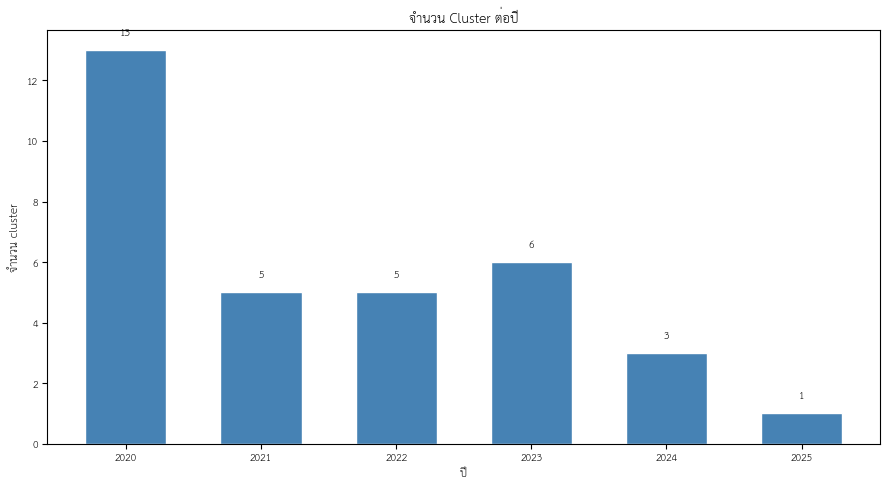

✓ บันทึก Cluster by Year Plot: D:\gistnu\ST-DBSCAN\file_final\Phase 4 Final\Output\plot_cluster_by_year.png


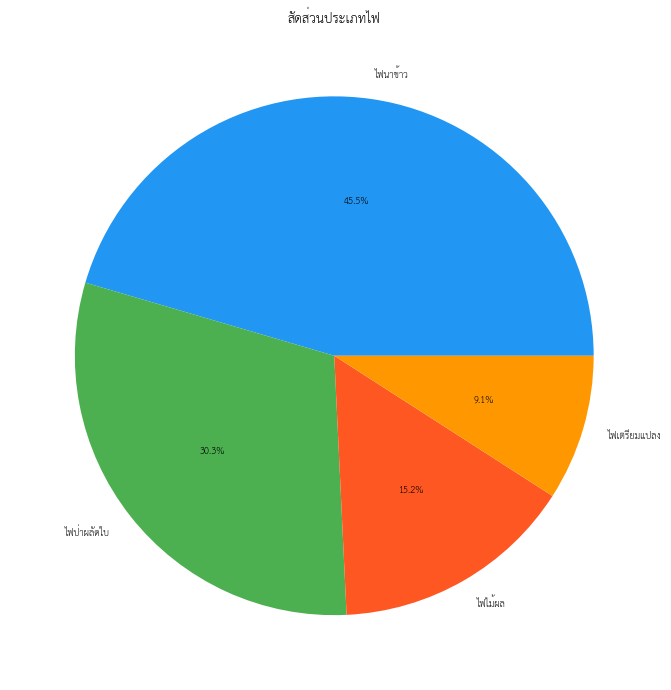

✓ บันทึก Fire Type Pie Plot: D:\gistnu\ST-DBSCAN\file_final\Phase 4 Final\Output\plot_fire_type_pie.png


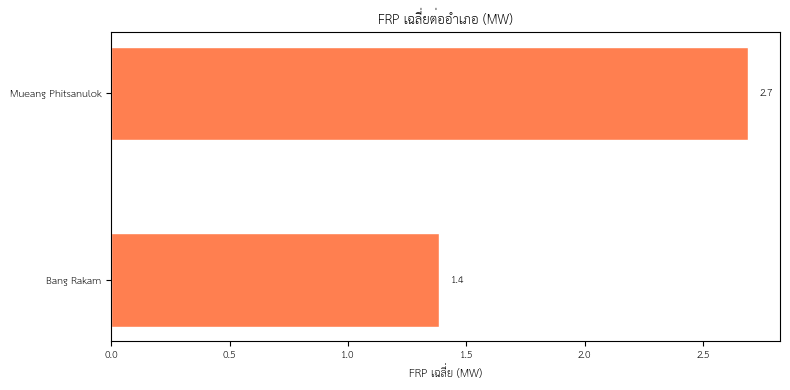

✓ บันทึก FRP by Amphoe Plot: D:\gistnu\ST-DBSCAN\file_final\Phase 4 Final\Output\plot_frp_by_amphoe.png


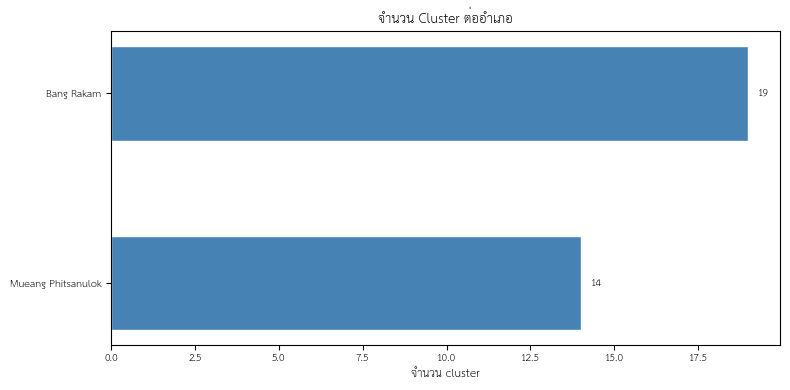

✓ บันทึก Cluster by Amphoe Plot: D:\gistnu\ST-DBSCAN\file_final\Phase 4 Final\Output\plot_cluster_by_amphoe.png


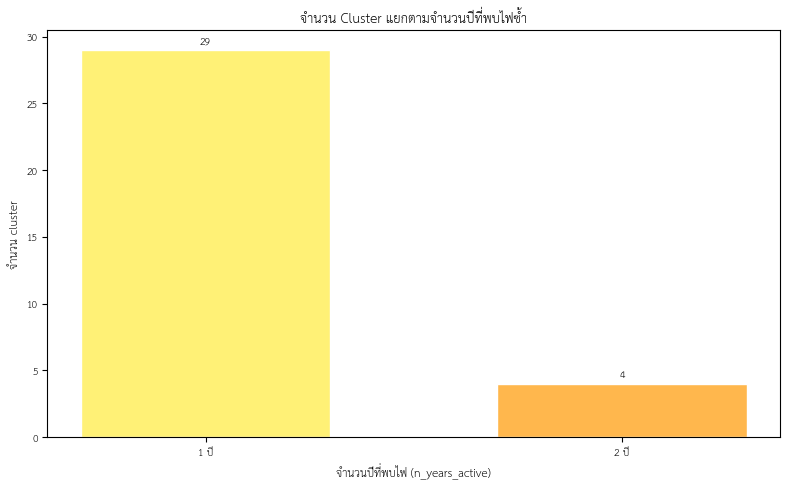

✓ บันทึก Repeat Burn Plot: D:\gistnu\ST-DBSCAN\file_final\Phase 4 Final\Output\plot_repeat_burn.png


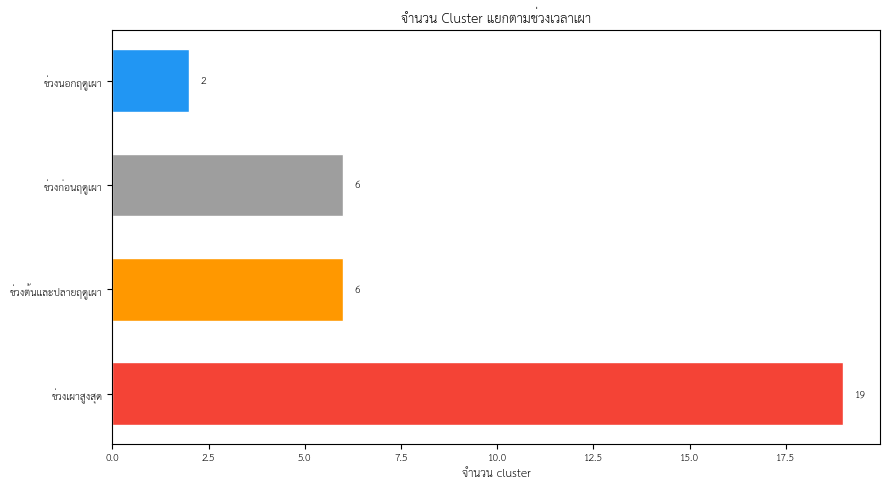

✓ บันทึก Burn Season Plot: D:\gistnu\ST-DBSCAN\file_final\Phase 4 Final\Output\plot_burn_season.png


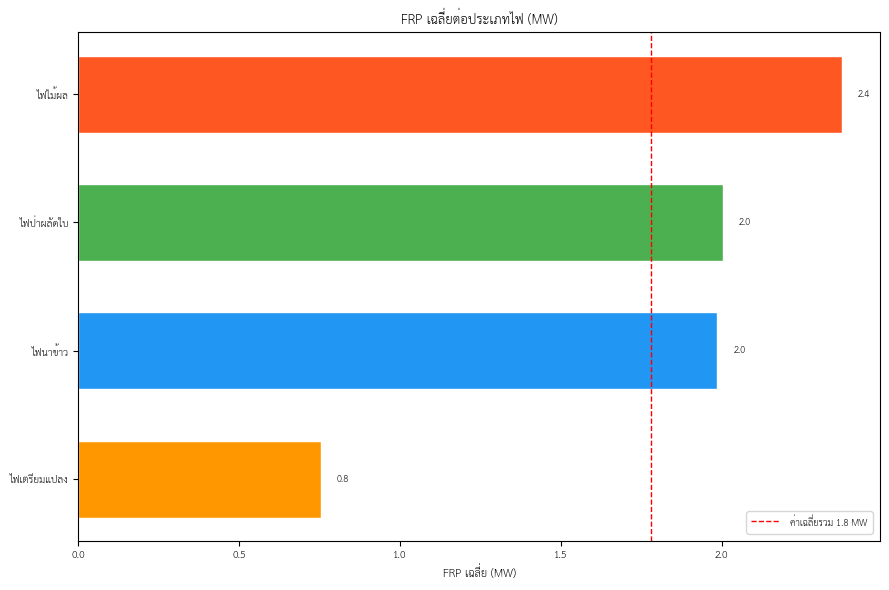

✓ บันทึก FRP by Fire Plot: D:\gistnu\ST-DBSCAN\file_final\Phase 4 Final\Output\plot_frp_by_fire.png


In [15]:
# CELL 7 — Static Plot สรุป
# Static Plot 1: จำนวน Cluster ต่อปี
fig, ax = plt.subplots(figsize=(9, 5))

year_summary = df_cluster.groupby('year')['cluster_id'].count()
ax.bar(year_summary.index, year_summary.values, color='steelblue', edgecolor='white', width=0.6)
for yr, cnt in zip(year_summary.index, year_summary.values):
    ax.text(yr, cnt + 0.5, str(cnt), ha='center', fontsize=11)
if 2026 in year_summary.index:
    ax.annotate('*ข้อมูลไม่ครบปี',
                xy=(2026, year_summary[2026]),
                xytext=(2024.8, year_summary[2026] + 8),
                fontsize=9, color='red',
                arrowprops=dict(arrowstyle='->', color='red', lw=1))

ax.set_title('จำนวน Cluster ต่อปี', fontsize=14)
ax.set_xlabel('ปี', fontsize=12)
ax.set_ylabel('จำนวน cluster', fontsize=12)
ax.set_xticks(year_summary.index)
ax.tick_params(labelsize=11)

plt.tight_layout()
PATH_PLOT_YEAR = os.path.join(OUTPUT_DIR, 'plot_cluster_by_year.png')
plt.savefig(PATH_PLOT_YEAR, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ บันทึก Cluster by Year Plot: {PATH_PLOT_YEAR}")

# Static Plot 2: สัดส่วนประเภทไฟ
fig, ax = plt.subplots(figsize=(9, 7))

fb_counts = df_cluster['fire_behavior'].value_counts()
colors    = [FIRE_COLORS.get(fb, '#cccccc') for fb in fb_counts.index]
ax.pie(fb_counts.values, labels=fb_counts.index,
       colors=colors, autopct='%1.1f%%',
       textprops={'fontsize': 10})
ax.set_title('สัดส่วนประเภทไฟ', fontsize=14)

plt.tight_layout()
PATH_PLOT_PIE = os.path.join(OUTPUT_DIR, 'plot_fire_type_pie.png')
plt.savefig(PATH_PLOT_PIE, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ บันทึก Fire Type Pie Plot: {PATH_PLOT_PIE}")

# Static Plot 3: FRP เฉลี่ยต่ออำเภอ
fig, ax = plt.subplots(figsize=(8, 4))

amphoe_frp = df_cluster.groupby('amphoe')['frp_mean'].mean().sort_values(ascending=True)
ax.barh(amphoe_frp.index, amphoe_frp.values, color='coral', edgecolor='white', height=0.5)
for i, (amp, val) in enumerate(zip(amphoe_frp.index, amphoe_frp.values)):
    ax.text(val + 0.05, i, f'{val:.1f}', va='center', fontsize=11)

ax.set_title('FRP เฉลี่ยต่ออำเภอ (MW)', fontsize=14)
ax.set_xlabel('FRP เฉลี่ย (MW)', fontsize=12)
ax.tick_params(labelsize=11)

plt.tight_layout()
PATH_PLOT_AMPHOE_FRP = os.path.join(OUTPUT_DIR, 'plot_frp_by_amphoe.png')
plt.savefig(PATH_PLOT_AMPHOE_FRP, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ บันทึก FRP by Amphoe Plot: {PATH_PLOT_AMPHOE_FRP}")

# Static Plot 4: จำนวน Cluster ต่ออำเภอ
fig, ax = plt.subplots(figsize=(8, 4))

amphoe_cluster = df_cluster.groupby('amphoe')['cluster_id'].count().sort_values(ascending=True)
ax.barh(amphoe_cluster.index, amphoe_cluster.values, color='steelblue', edgecolor='white', height=0.5)
for i, (amp, cnt) in enumerate(zip(amphoe_cluster.index, amphoe_cluster.values)):
    ax.text(cnt + 0.3, i, str(cnt), va='center', fontsize=11)

ax.set_title('จำนวน Cluster ต่ออำเภอ', fontsize=14)
ax.set_xlabel('จำนวน cluster', fontsize=12)
ax.tick_params(labelsize=11)

plt.tight_layout()
PATH_PLOT_AMPHOE_CNT = os.path.join(OUTPUT_DIR, 'plot_cluster_by_amphoe.png')
plt.savefig(PATH_PLOT_AMPHOE_CNT, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ บันทึก Cluster by Amphoe Plot: {PATH_PLOT_AMPHOE_CNT}")

# Static Plot 5: Repeat Burn Distribution
fig, ax = plt.subplots(figsize=(8, 5))

repeat_colors = {1: '#FFF176', 2: '#FFB74D', 3: '#FF7043', 4: '#E53935', 5: '#B71C1C'}
repeat_counts = df_cluster['n_years_active'].value_counts().sort_index()

bars = ax.bar(
    repeat_counts.index, repeat_counts.values,
    color=[repeat_colors.get(n, '#B71C1C') for n in repeat_counts.index],
    edgecolor='white', width=0.6
)
for bar, cnt in zip(bars, repeat_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(cnt), ha='center', fontsize=11)

ax.set_title('จำนวน Cluster แยกตามจำนวนปีที่พบไฟซ้ำ', fontsize=14)
ax.set_xlabel('จำนวนปีที่พบไฟ (n_years_active)', fontsize=12)
ax.set_ylabel('จำนวน cluster', fontsize=12)
ax.set_xticks(repeat_counts.index)
ax.set_xticklabels([f'{n} ปี' for n in repeat_counts.index], fontsize=11)
ax.tick_params(labelsize=11)

plt.tight_layout()
PATH_PLOT_REPEAT = os.path.join(OUTPUT_DIR, 'plot_repeat_burn.png')
plt.savefig(PATH_PLOT_REPEAT, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ บันทึก Repeat Burn Plot: {PATH_PLOT_REPEAT}")

# Static Plot 6: Burn Season Distribution
fig, ax = plt.subplots(figsize=(9, 5))

season_colors_map = {
    'ช่วงเตรียมแปลงก่อนฤดูแล้ง' : '#9C27B0',
    'ช่วงก่อนฤดูแล้ง'            : '#26A69A',
    'ช่วงเผาสูงสุด'               : '#F44336',
    'ช่วงต้นและปลายฤดูเผา'        : '#FF9800',
    'ช่วงนอกฤดูเผา'               : '#2196F3',
}

season_counts = df_cluster['burn_season_label'].value_counts()
colors = [season_colors_map.get(s, '#9E9E9E') for s in season_counts.index]

bars = ax.barh(season_counts.index, season_counts.values,
               color=colors, edgecolor='white', height=0.6)
for bar, cnt in zip(bars, season_counts.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(cnt), va='center', fontsize=11)

ax.set_title('จำนวน Cluster แยกตามช่วงเวลาเผา', fontsize=14)
ax.set_xlabel('จำนวน cluster', fontsize=12)
ax.tick_params(labelsize=11)

plt.tight_layout()
PATH_PLOT_SEASON = os.path.join(OUTPUT_DIR, 'plot_burn_season.png')
plt.savefig(PATH_PLOT_SEASON, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ บันทึก Burn Season Plot: {PATH_PLOT_SEASON}")

# Static Plot 7: FRP เฉลี่ยต่อประเภทไฟ
fig, ax = plt.subplots(figsize=(9, 6))

frp_by_fire = (df_cluster.groupby('fire_behavior')['frp_mean']
               .mean()
               .sort_values(ascending=True))
colors = [FIRE_COLORS.get(fb, '#9E9E9E') for fb in frp_by_fire.index]

bars = ax.barh(frp_by_fire.index, frp_by_fire.values,
               color=colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, frp_by_fire.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=10)

ax.set_title('FRP เฉลี่ยต่อประเภทไฟ (MW)', fontsize=14)
ax.set_xlabel('FRP เฉลี่ย (MW)', fontsize=12)
ax.tick_params(labelsize=11)
ax.axvline(frp_by_fire.mean(), color='red', linestyle='--',
           linewidth=1, label=f'ค่าเฉลี่ยรวม {frp_by_fire.mean():.1f} MW')
ax.legend(fontsize=10)

plt.tight_layout()
PATH_PLOT_FRP = os.path.join(OUTPUT_DIR, 'plot_frp_by_fire.png')
plt.savefig(PATH_PLOT_FRP, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ บันทึก FRP by Fire Plot: {PATH_PLOT_FRP}")

In [16]:
# Export CSV
amphoe_summary = df_cluster.groupby('amphoe').agg(
    n_cluster  = ('cluster_id',    'count'),
    area_total = ('area_rai',      'sum'),
    frp_mean   = ('frp_mean',      'mean'),
    main_fire  = ('fire_behavior', lambda x: x.mode()[0]),
    repeat_cnt = ('repeat_burn',   'sum'),
).reset_index().round(2)
PATH_AMPHOE = os.path.join(OUTPUT_DIR, 'summary_by_amphoe.csv')
amphoe_summary.to_csv(PATH_AMPHOE, index=False, encoding='utf-8-sig')
print(f"✓ Export amphoe summary: {PATH_AMPHOE}")

year_full = df_cluster.groupby('year').agg(
    n_cluster  = ('cluster_id',    'count'),
    area_total = ('area_rai',      'sum'),
    frp_mean   = ('frp_mean',      'mean'),
    main_fire  = ('fire_behavior', lambda x: x.mode()[0])
).reset_index().round(2)
PATH_YEAR = os.path.join(OUTPUT_DIR, 'summary_by_year.csv')
year_full.to_csv(PATH_YEAR, index=False, encoding='utf-8-sig')
print(f"✓ Export year summary: {PATH_YEAR}")

fire_full = df_cluster.groupby('fire_behavior').agg(
    n_cluster     = ('cluster_id',    'count'),
    area_mean     = ('area_rai',      'mean'),
    area_total    = ('area_rai',      'sum'),
    duration_mean = ('duration_days', 'mean'),
    frp_mean      = ('frp_mean',      'mean'),
    agri_mean     = ('agri_ratio',    'mean'),
).reset_index().round(2)
PATH_FIRE = os.path.join(OUTPUT_DIR, 'summary_by_fire_type.csv')
fire_full.to_csv(PATH_FIRE, index=False, encoding='utf-8-sig')
print(f"✓ Export fire type summary: {PATH_FIRE}")

✓ Export amphoe summary: D:\gistnu\ST-DBSCAN\file_final\Phase 4 Final\Output\summary_by_amphoe.csv
✓ Export year summary: D:\gistnu\ST-DBSCAN\file_final\Phase 4 Final\Output\summary_by_year.csv
✓ Export fire type summary: D:\gistnu\ST-DBSCAN\file_final\Phase 4 Final\Output\summary_by_fire_type.csv


In [17]:
# CHECKPOINT FINAL
print("\n[CHECKPOINT FINAL] ตรวจสอบ Output ทั้งหมด")
outputs = {
    'Map 1 (พฤติกรรมไฟ)'      : os.path.join(OUTPUT_DIR, 'map1_hotspot_by_fire_type.html'),
    'Map 2 (พื้นที่เผาซ้ำ)'    : os.path.join(OUTPUT_DIR, 'map2_repeat_burn.html'),
    'Map 3 (ปฏิทินไฟ)'      : os.path.join(OUTPUT_DIR, 'map3_burn_season.html'),
    'Map 4 (ความรุนแรง FRP)'            : os.path.join(OUTPUT_DIR, 'map4_frp_intensity.html'),
    'Dashboard'              : os.path.join(OUTPUT_DIR, 'dashboard.html'),
    'Plot: Cluster by Year'  : PATH_PLOT_YEAR,
    'Plot: Fire Type Pie'    : PATH_PLOT_PIE,
    'Plot: FRP by Amphoe'    : PATH_PLOT_AMPHOE_FRP,
    'Plot: Cluster by Amphoe': PATH_PLOT_AMPHOE_CNT,
    'Plot: Repeat Burn'      : PATH_PLOT_REPEAT,
    'Plot: Burn Season'      : PATH_PLOT_SEASON,
    'Plot: FRP by Fire'      : PATH_PLOT_FRP,
    'Amphoe CSV'             : PATH_AMPHOE,
    'Year CSV'               : PATH_YEAR,
    'Fire Type CSV'          : PATH_FIRE,
}
all_ok = True
for name, path in outputs.items():
    status = "✓" if os.path.exists(path) else "✗"
    if status == "✗":
        all_ok = False
    print(f"  {status} {name}: {os.path.basename(path)}")

print(f"\n{'='*60}")
print(f"สรุปผล Phase 4:")
print(f"  Interactive Map : 4 แผนที่ + 1 dashboard")
print(f"  Static Plot     : 7 ภาพ")
print(f"  CSV Export      : 3 ไฟล์")
print(f"  Output folder   : {OUTPUT_DIR}")
print(f"{'='*60}")
if all_ok:
    print("✓ Phase 4 เสร็จสมบูรณ์ — โปรเจกต์เสร็จแล้ว!")
else:
    print("✗ มีบาง output ที่ยังไม่ครบ กรุณาตรวจสอบ")


[CHECKPOINT FINAL] ตรวจสอบ Output ทั้งหมด
  ✓ Map 1 (พฤติกรรมไฟ): map1_hotspot_by_fire_type.html
  ✓ Map 2 (พื้นที่เผาซ้ำ): map2_repeat_burn.html
  ✓ Map 3 (ปฏิทินไฟ): map3_burn_season.html
  ✓ Map 4 (ความรุนแรง FRP): map4_frp_intensity.html
  ✓ Dashboard: dashboard.html
  ✓ Plot: Cluster by Year: plot_cluster_by_year.png
  ✓ Plot: Fire Type Pie: plot_fire_type_pie.png
  ✓ Plot: FRP by Amphoe: plot_frp_by_amphoe.png
  ✓ Plot: Cluster by Amphoe: plot_cluster_by_amphoe.png
  ✓ Plot: Repeat Burn: plot_repeat_burn.png
  ✓ Plot: Burn Season: plot_burn_season.png
  ✓ Plot: FRP by Fire: plot_frp_by_fire.png
  ✓ Amphoe CSV: summary_by_amphoe.csv
  ✓ Year CSV: summary_by_year.csv
  ✓ Fire Type CSV: summary_by_fire_type.csv

สรุปผล Phase 4:
  Interactive Map : 4 แผนที่ + 1 dashboard
  Static Plot     : 7 ภาพ
  CSV Export      : 3 ไฟล์
  Output folder   : D:\gistnu\ST-DBSCAN\file_final\Phase 4 Final\Output
✓ Phase 4 เสร็จสมบูรณ์ — โปรเจกต์เสร็จแล้ว!
